<a href="https://colab.research.google.com/github/DrAmitaB/AIML/blob/main/DrAmitaBeloskarPevekar_Loan_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Problem Staement

##1.1 Business Context

AllLife Bank is a fast-growing mid-sized retail bank in the United States that provides financial services such as savings accounts, checking accounts, fixed deposits, and personal loans. The bank currently has a strong base of liability customers (depositors), but the number of asset customers (borrowers) is comparatively low. Since personal loans generate significant interest income, expanding the loan portfolio has become a major business priority for the bank.

To improve profitability, the bank launched a pilot marketing campaign last year to encourage existing deposit customers to take personal loans. The campaign achieved a conversion rate of 9%, showing strong potential for growth. However, conducting large-scale campaigns for all customers is costly and inefficient. Therefore, the marketing team now requires a more data-driven approach to identify customers who are most likely to accept a personal loan offer.

By understanding customer demographics, financial behavior, and banking patterns, the bank aims to optimize marketing efforts, reduce unnecessary campaign spending, improve conversion rates, and maximize customer lifetime value.

##1.2 Objective

The primary objective of this project is to build a predictive classification model that can identify customers who are likely to accept a personal loan offer. The model will analyze customer demographic and behavioral attributes to uncover the key factors influencing loan acceptance.

The insights generated from the analysis will help the bank:

- Identify high-potential customers for personal loan campaigns.
- Improve the efficiency and success rate of marketing campaigns.
- Reduce marketing costs by targeting the right audience.
- Enhance profitability through increased loan conversions.
- Support data-driven decision-making for customer segmentation and campaign planning.

The final goal is to help AllLife Bank achieve sustainable business growth by effectively converting existing deposit customers into personal loan customers.

##1.3 Data Description

| Column Name          | Description                                                                                                  |
| -------------------- | ------------------------------------------------------------------------------------------------------------ |
| `ID`                 | Unique identification number assigned to each customer                                                       |
| `Age`                | Age of the customer in completed years                                                                       |
| `Experience`         | Total years of professional work experience                                                                  |
| `Income`             | Annual income of the customer (in thousand dollars)                                                          |
| `ZIP Code`           | Residential ZIP code of the customer                                                                         |
| `Family`             | Number of family members                                                                                     |
| `CCAvg`              | Average monthly credit card spending (in thousand dollars)                                                   |
| `Education`          | Education level of the customer:<br>1 = Undergraduate<br>2 = Graduate<br>3 = Advanced/Professional           |
| `Mortgage`           | Mortgage value of the customer’s house (in thousand dollars)                                                 |
| `Personal_Loan`      | Target variable indicating whether the customer accepted the personal loan offer:<br>0 = No<br>1 = Yes       |
| `Securities_Account` | Indicates whether the customer has a securities account with the bank:<br>0 = No<br>1 = Yes                  |
| `CD_Account`         | Indicates whether the customer has a Certificate of Deposit (CD) account with the bank:<br>0 = No<br>1 = Yes |
| `Online`             | Indicates whether the customer uses online banking services:<br>0 = No<br>1 = Yes                            |
| `CreditCard`         | Indicates whether the customer uses a credit card issued by another bank:<br>0 = No<br>1 = Yes               |


#2. Data Understanding

##2.1 Importing Necessary Libraries

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

##2.2 Loading Of Dataset

In [ ]:
data = pd.read_csv('/content/Loan_Modelling.csv')

##2.3 Copy of Dataset

In [ ]:
df = data.copy()

##2.4 View First and Last 5 rows of Dataset

In [ ]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
df.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


Observation:

- ID is only a unique identifier and does not contribute to prediction.
- ZIPCode represents geographical information but may not provide meaningful predictive value in its current numerical form and can later be appropriately handled during preprocessing.
- Features such as:
  - Education,
  - Securities_Account,
  - CD_Account,
  - Online,
  - CreditCard

represent categorical/binary information even though they are stored as integers.
- The target variable is: Personal Loan, which indicates whether a customer accepted the personal loan offer.
- The memory usage of the dataset is relatively low (547 KB), indicating that the dataset is lightweight and computationally efficient to process.

##2.5 Check Shape of Dataset

In [ ]:
df.shape

(5000, 14)

Observation:
- There are total 5000 rows and 14 columns in the dataset.

##2.6 Check Data types of the Columns of the Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


Observation:
- The dataset contains 5000 rows and 14 columns, indicating that information for 5000 customers is available for analysis.
- All columns have 5000 non-null values, which means:
  - There are no missing values in the dataset.
  - Missing value treatment is not required.
- The dataset contains:
  - 13 integer (int64) columns
  - 1 float (float64) column, which is CCAvg.
- The CCAvg feature is stored as a float because it represents average credit card spending, which can contain decimal values.
- Most variables are numerical in nature, making them directly suitable for Decision Tree modeling without extensive preprocessing.




##2.7 Check of Missing Values

In [ ]:
# Checking for null values
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


Observation:
- There are no missing values in the dataset

##2.8 Check for Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

Observation:
- There are no duplicate values

##2.9 Check for Unique Values

In [ ]:
# Loop through all the columns present in the dataframe

for col in df.columns:


    # Print the name of the current column

    print(f"\nColumn Name : {col}")


    # Print the total number of unique/distinct values present in that column

    print(f"Number of Unique Values : {df[col].nunique()}")


    # Print all the unique values present in the column

    print(f"Unique Values : {df[col].unique()}")


    # Print a separator line for better readability of output

    print("-" * 70)


Column Name : ID
Number of Unique Values : 5000
Unique Values : [   1    2    3 ... 4998 4999 5000]
----------------------------------------------------------------------

Column Name : Age
Number of Unique Values : 45
Unique Values : [25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
----------------------------------------------------------------------

Column Name : Experience
Number of Unique Values : 47
Unique Values : [ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
----------------------------------------------------------------------

Column Name : Income
Number of Unique Values : 162
Unique Values : [ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  3

####Observations from Unique Values Analysis

- The dataset contains a mix of:

  - Numerical variables
  - Ordinal categorical variables
  - Binary categorical variables

This combination makes the dataset suitable for Decision Tree Classification.

1. ID:
- The ID column contains 5000 unique values, meaning each customer has a unique identifier.
- Since all values are unique, this column does not contribute meaningful predictive information for the model.
####Observation

- ID acts only as a customer identifier and can be removed.

2. Age:
- The Age column contains 45 unique values ranging from 23 to 67 years.
- This indicates a diverse customer base consisting mainly of working-age individuals.
####Observation

- Customers belong to a broad range of age groups, which may influence loan purchasing behavior.

3. Experience:
- The Experience column contains 47 unique values ranging from -3 to 43 years.
- Negative values are present (-1, -2, -3), which are logically invalid.
####Observation

- Negative experience values indicate data inconsistencies or data entry errors and require preprocessing treatment.

4. Income:
- The Income column contains 162 unique values, showing strong variability in customer income levels.
- Income ranges from 8 thousand dollars to 224 thousand dollars.
####Observation

- The dataset includes customers from various income groups, which can strongly impact personal loan acceptance.

5. ZIPCode:
- The ZIPCode column contains 467 unique values, indicating customers belong to multiple geographical regions.
- ZIP codes represent location-based information that may influence customer financial behavior and loan purchasing patterns.
####Observation

- Instead of using raw ZIP codes directly, the feature will be transformed into more meaningful geographical attributes such as City and State. This transformation improves interpretability and allows the model to capture regional customer behavior more effectively.

6. Family:
- The Family column contains - - only 4 unique values:
1
2
3
4
####Observation

- Family sizes are limited to small household categories and may influence financial requirements and loan interest.

7. CCAvg:
- The CCAvg column contains 108 unique values, indicating variation in customer credit card spending behavior.
- Values range from very low spending to high spending levels.
####Observation

- Credit card spending patterns may help identify financially active customers who are more likely to accept loans.

8. Education:
- The Education column contains - 3 unique categories:
1 = Undergraduate
2 = Graduate
3 = Advanced/Professional
####Observation

- Education is an ordinal categorical variable and may significantly influence customer financial behavior and loan acceptance.

9. Mortgage:
- The Mortgage column contains 347 unique values, showing large variation in mortgage amounts.
- Many customers have mortgage value 0, while some possess very high mortgage amounts.
####Observation

- Mortgage values vary significantly among customers, indicating different levels of financial liabilities.

10. Personal_Loan:
- The target variable contains - only 2 unique values:
0 = Loan not accepted
1 = Loan accepted
####Observation

- This confirms that the project is a binary classification problem.

11. Securities_Account:
- It contains:
0 = No
1 = Yes
####Observation

- This is a binary categorical variable indicating whether a customer holds a securities account.

12. CD_Account:
- It contains:
0 = No
1 = Yes
####Observation

- This binary variable may strongly influence loan acceptance behavior.

13. Online:
- It contains:
0 = No
1 = Yes
####Observation

- Indicates whether customers use online banking services, which may help identify digitally active customers.

14. CreditCard:
- It contains:
0 = No
1 = Yes
####Observation

- Represents whether customers use credit cards from other banks and may reflect customer banking preferences.



###2.9.1 Dropping the column with all unique values

In [ ]:
df = df.drop('ID', axis=1)


Observation:
- ID column is removed from dataset as it contains unique values, which is redundant data.

In [ ]:
# checking ID column is removed from dataset
df.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


##2.10 Statistical Summary of Data

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


###Observations:
Numerical Feature Insights
1. Age
- Average customer age is approximately 45 years.
- The youngest customer is 23 years, while the oldest is 67 years.
- Most customers fall between 35 and 55 years based on quartile values.
- The distribution appears relatively balanced without extreme variation.
2. Experience
- Average professional experience is around 20 years.
- The minimum value is -3, which is logically incorrect because experience cannot be negative.
- This indicates the presence of anomalous values or data entry errors and may require treatment or further investigation.
3. Income
- Average annual income is approximately 74 thousand dollars.
- Income ranges from 8 thousand dollars to 224 thousand dollars.
- High standard deviation indicates large income variation among customers.
- Presence of high-income customers suggests possible outliers.
4. ZIPCode
- ZIPCode values range from 90005 to 96651.
- Since ZIP codes are identifiers/geographical codes rather than continuous numerical variables, statistical measures like mean and standard deviation are not meaningful for this feature.
5. Family
- Family size ranges from 1 to 4 members.
- Most customers have family sizes between 1 and 3.
- Average family size is approximately 2.4 members.
6. CCAvg
- Average monthly credit card spending is approximately 1.94 thousand dollars.
- Some customers spend as high as 10 thousand dollars, indicating potential outliers.
- The distribution is likely positively skewed.
7. Education
- Education values range from 1 to 3, representing ordinal categories:
1 = Undergraduate,
2 = Graduate, and
3 = Advanced/Professional
- Median education level is 2, indicating most customers are graduates.
8. Mortgage
- Mortgage values range from 0 to 635 thousand dollars.
- The median mortgage value is 0, indicating that more than half of the customers do not have mortgages.
- High maximum values indicate strong right skewness and possible outliers.
9. Personal_Loan
- Mean value is 0.096, meaning approximately 9.6% customers accepted the personal loan offer.
- This indicates:
  - The dataset is imbalanced
  - Majority customers did not accept the loan

This aligns with the business context where the previous campaign had a relatively low conversion rate.

Binary Variable Insights:

10. Securities_Account
- Only around 10.4% customers have a securities account.
11. CD_Account
- Only around 6% customers have a CD account.
- This feature may still be highly important for prediction despite low frequency.
12. Online
- Approximately 59.7% customers use online banking services.
- Indicates digital banking adoption is relatively high.
13. CreditCard
- Around 29.4% customers use credit cards from other banks.

#3. Exploratory Data Analysis (EDA)

##3.1 Univariate Analysis

###Numerical Columns

In [ ]:
numerical_cols = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

###3.1.1 Histograms for Numerical Variables

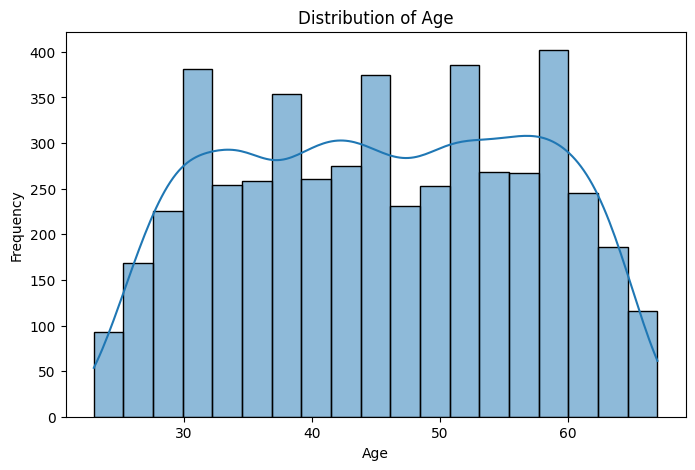

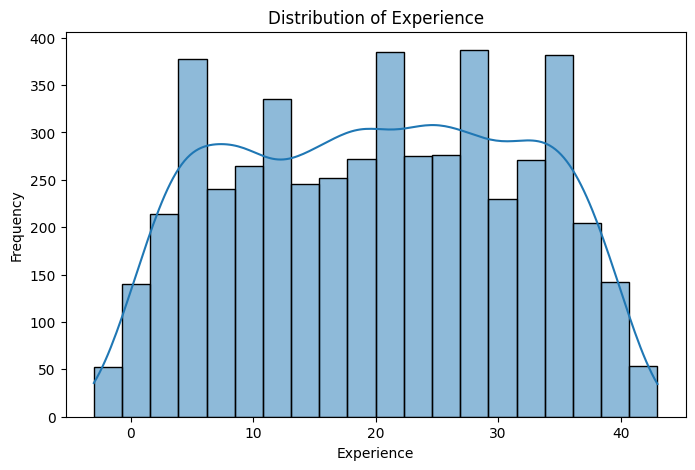

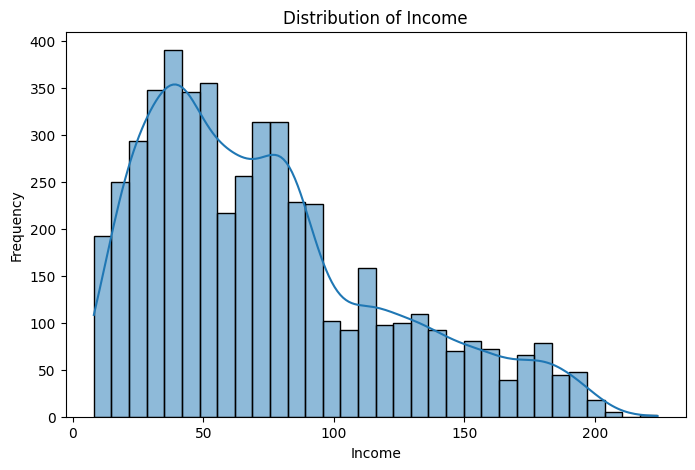

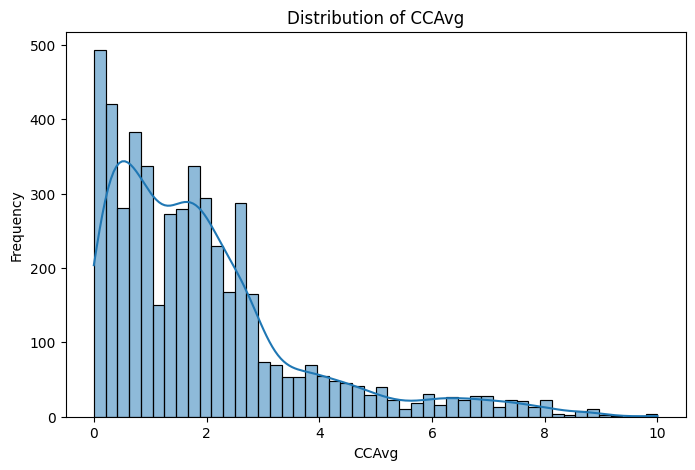

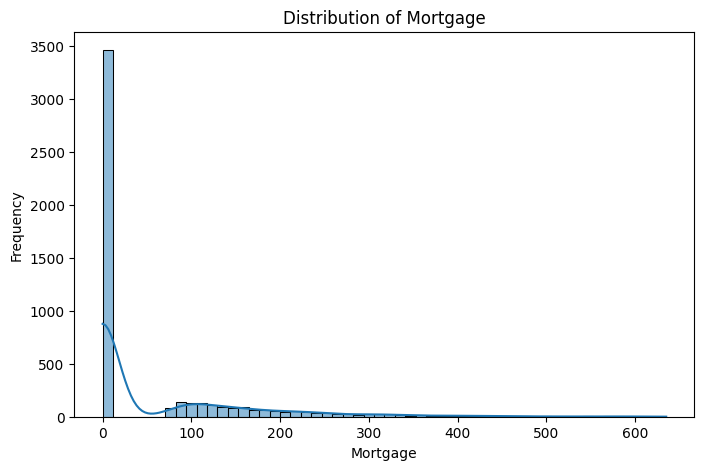

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

####Observations from Histogram Plots:
1. Distribution of Age

- The Age variable appears to be fairly uniformly distributed across different age groups.
- Most customers fall between the age range of 30 to 60 years.
- The distribution does not show significant skewness.
- No extreme outliers are visible in the distribution.
- The dataset contains customers from a broad working-age population.

2. Distribution of Experience

- The Experience variable is relatively evenly distributed across different experience levels.
- Most customers have experience ranging between 5 and 35 years.
- A few negative experience values are present, which are logically incorrect and indicate data inconsistencies or entry errors.
- The distribution otherwise appears balanced without major skewness.
####Important Insight

- Negative values in professional experience are anomalous and should be handled during preprocessing.

3. Distribution of Income

- The Income variable is positively skewed (right-skewed).
- Most customers belong to lower and middle income groups.
- A smaller number of customers have very high incomes.
- The long right tail indicates the presence of high-income outliers.
- Income variability among customers is high.
####Insight

- Higher-income customers may have greater purchasing power and could be more likely to accept personal loan offers.

4. Distribution of CCAvg

- The CCAvg variable is heavily right-skewed.
- Most customers have relatively low average credit card spending.
- A small group of customers spend significantly higher amounts on credit cards.
- Presence of extreme spending values suggests potential outliers.
####Insight

- Customers with higher credit card spending may represent financially active customers and could be potential targets for loan campaigns.

5. Distribution of Mortgage

- The Mortgage variable is extremely right-skewed.
- A large number of customers have zero mortgage value.
- Only a small portion of customers possess high mortgage amounts.
- The distribution contains significant outliers and a long right tail.
####Insight

- The majority of customers do not own mortgages, while a smaller segment has very high mortgage commitments.

####Overall Conclusion from Numerical Distributions
- Income, CCAvg, and Mortgage show strong positive skewness and contain outliers.
- Age and Experience are comparatively more balanced.
- The dataset contains considerable variability in customer financial behavior.
- Since Decision Tree models are generally robust to skewness and outliers, extensive scaling or normalization may not be necessary.

###3.1.2 Boxplots for Numerical Variables

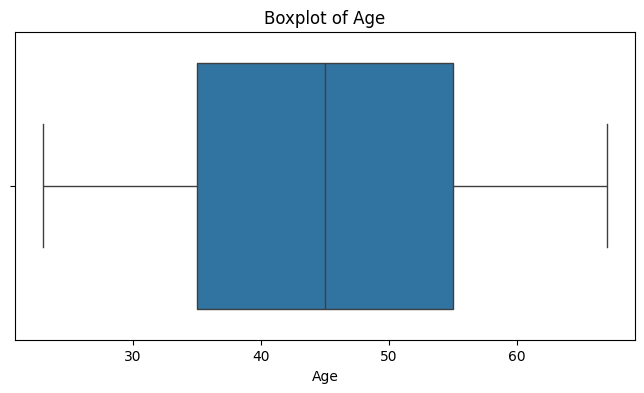

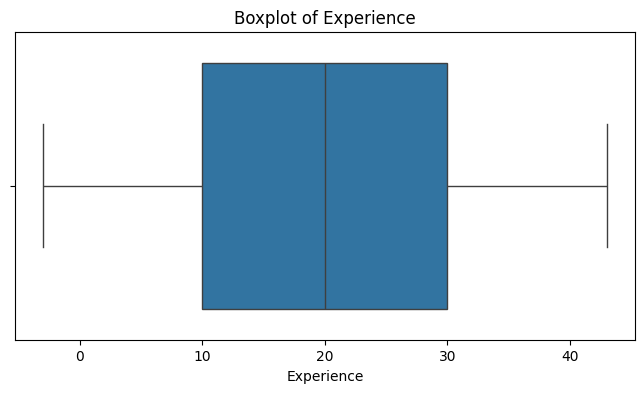

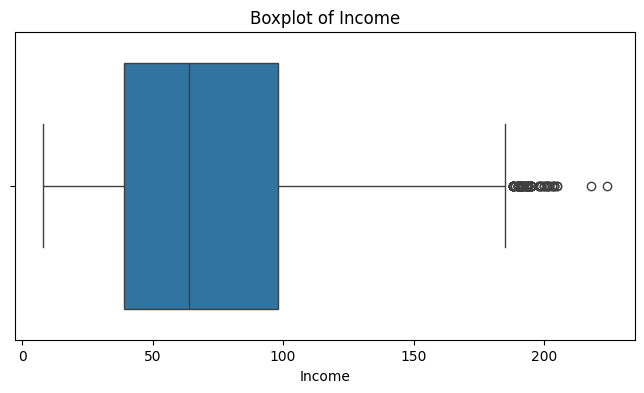

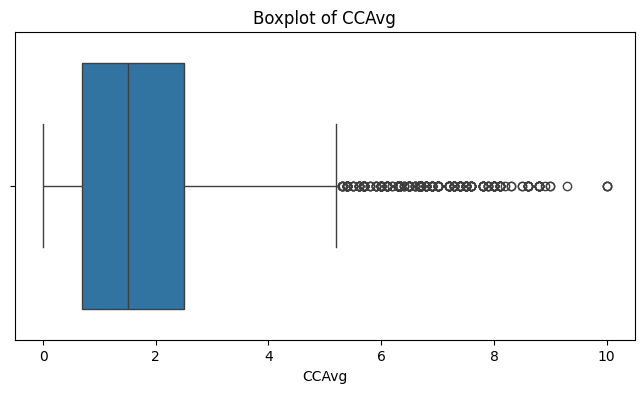

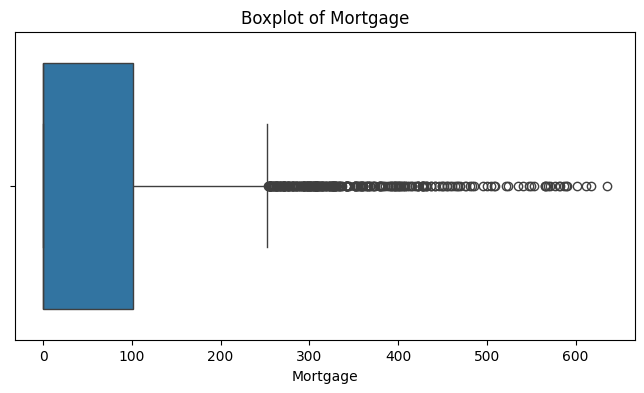

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

####Observations from Boxplots
1. Boxplot of Age

- The Age variable does not show significant outliers.
- The median age is around 45 years.
- Most customers fall within the age range of approximately 35 to 55 years.
- The distribution appears fairly balanced and symmetric.
####Insight

- Customer ages are well distributed across working-age groups, and no extreme age anomalies are present.

2. Boxplot of Experience

- The Experience variable does not contain major outliers.
- However, negative experience values are visible, which are logically invalid.
- Most customers have professional experience between 10 and 30 years.
- The median experience is approximately 20 years.
####Insight

- Negative experience values indicate data inconsistencies and should be addressed during preprocessing.

3. Boxplot of Income

- The Income variable contains several upper-end outliers.
- Most customers have incomes below approximately 100 thousand dollars.
- A small number of customers have exceptionally high incomes above 180 thousand dollars.
- The distribution is positively skewed.
####Insight

- High-income customers form a smaller segment of the dataset and may have stronger loan purchasing capability.

4. Boxplot of CCAvg

- The CCAvg variable shows a large number of upper-end outliers.
- Most customers have monthly credit card spending below 3 thousand dollars.
- A few customers exhibit extremely high spending behavior up to 10 thousand dollars.
- The distribution is highly right-skewed.
####Insight

- Customers with very high credit card spending may represent financially active or premium customers and could be strong targets for personal loan campaigns.

5. Boxplot of Mortgage

- The Mortgage variable contains a substantial number of extreme outliers.
- Most customers have mortgage values close to zero.
- A small proportion of customers have very large mortgage amounts exceeding 250 thousand dollars.
- The distribution is heavily right-skewed.
####Insight

- The majority of customers do not possess mortgages, while a smaller segment has high mortgage liabilities.

####Overall Conclusion from Boxplots
- Income, CCAvg, and Mortgage contain significant upper-end outliers.
- Age and Experience are comparatively stable variables.
- Outliers are expected in financial datasets due to variation in customer financial behavior.
- Since Decision Tree models are relatively robust to outliers, aggressive outlier treatment may not be necessary.
- However, anomalous negative values in Experience should be treated separately as data inconsistencies rather than true outliers.

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?


###Observation for Mortgage Distribution
- Distribution Analysis:
  - The Mortgage feature is highly right-skewed.
  - A very large number of customers have mortgage values close to 0.
  - The frequency decreases significantly as mortgage values increase.
- Outlier Analysis
  - The boxplot shows a large number of extreme upper-end outliers.
  - Several customers possess very high mortgage values extending beyond 600.
- Pattern Identified
  - Most customers either:
    - do not have a mortgage, or
    - possess relatively low mortgage amounts.
    - Only a small segment of customers carries very large mortgage liabilities.
- Business Insight

  - Customers with high mortgage amounts may represent financially active customers with larger assets and liabilities, making them potential targets for personal loan offerings.



2. How many customers have credit cards?

###3.1.3 Countplots for Categorical Variables

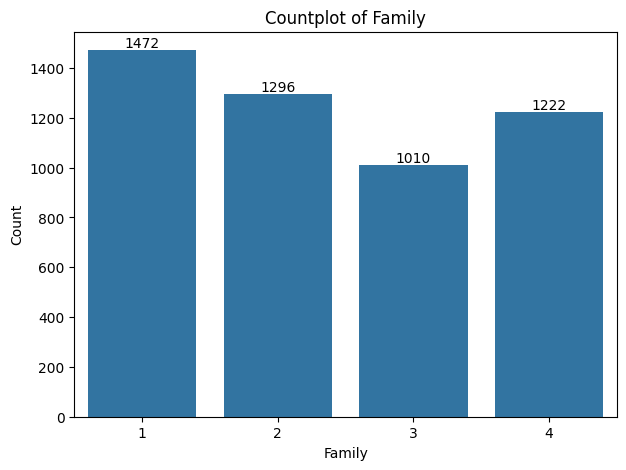

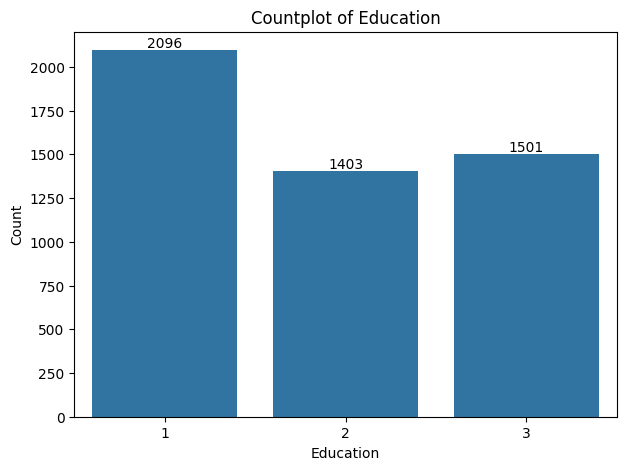

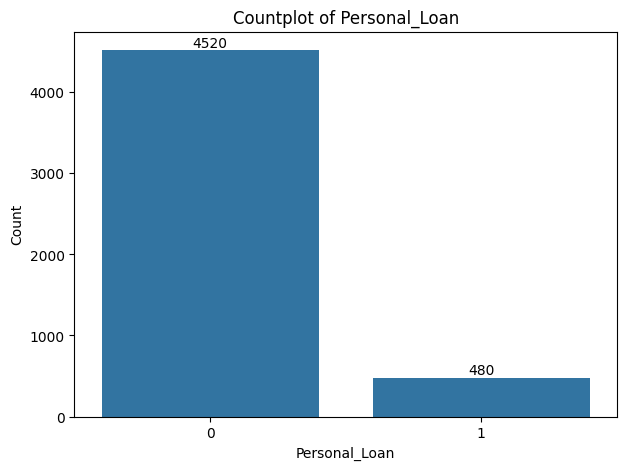

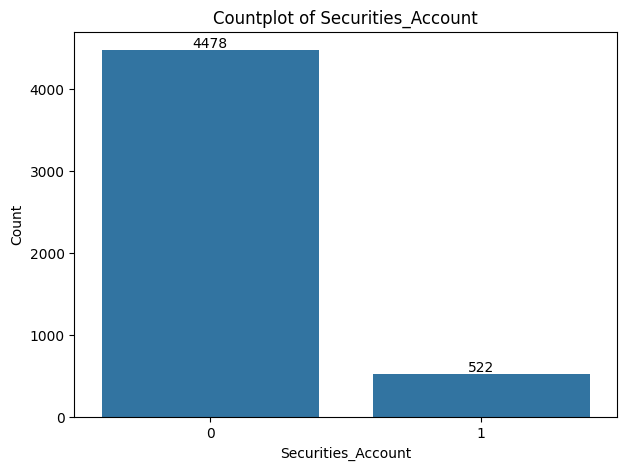

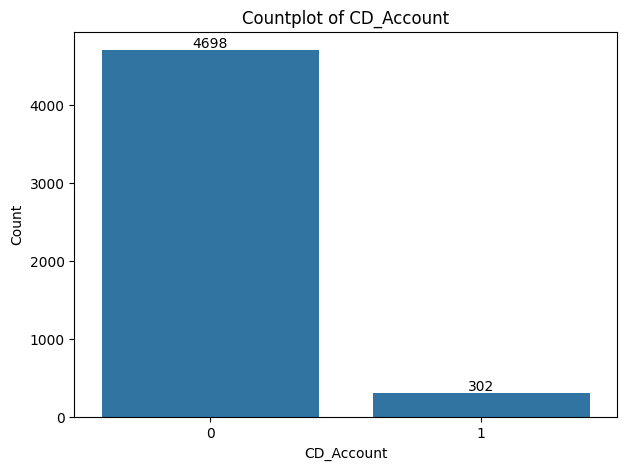

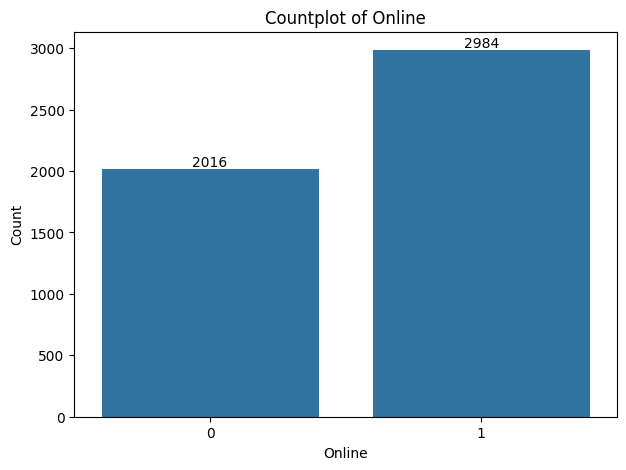

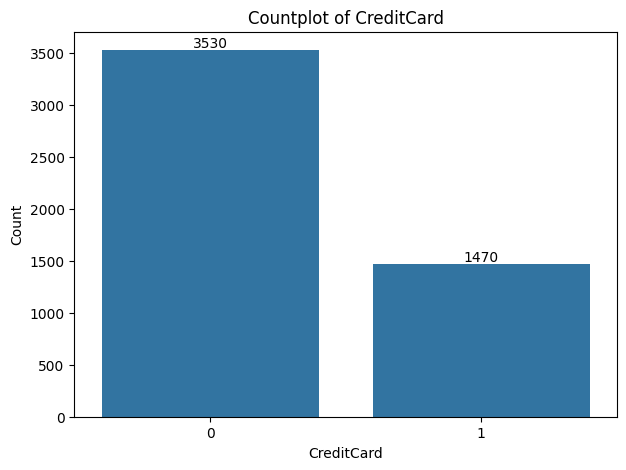

In [ ]:
categorical_cols = [
    'Family',
    'Education',
    'Personal_Loan',
    'Securities_Account',
    'CD_Account',
    'Online',
    'CreditCard'
]

for col in categorical_cols:

    plt.figure(figsize=(7,5))

    ax = sns.countplot(x=df[col])

    # Adding labels on top of bars
    for bars in ax.containers:
        ax.bar_label(bars)

    plt.title(f"Countplot of {col}")

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.show()

####Observations from Countplots
1. Countplot of Family

- Customers with
  - family size 1 are the highest in number with 1472 customers.
  - Family size 2 contains 1296 customers.
  - Family size 4 contains 1222 customers.
  - Family size 3 has the lowest count with 1010 customers.
####Insight

- The dataset contains customers from different family sizes, with smaller families being slightly more common. Family size may influence financial needs and borrowing behavior.

2. Countplot of Education

- Education level 1 (Undergraduate) has the highest count with 2096 customers.
- Education level 3 (Advanced/Professional) contains 1501 customers.
- Education level 2 (Graduate) contains 1403 customers.
####Insight

- Undergraduate customers dominate the dataset, but higher education levels are also well represented. Education may significantly influence loan acceptance behavior.

3. Countplot of Personal_Loan

- 4520 customers did not accept the personal loan offer (0).
- Only 480 customers accepted the loan (1).
####Insight

- The target variable is highly imbalanced, with a much larger number of non-loan customers. This reflects the low conversion rate of the previous marketing campaign.

4. Countplot of Securities_Account

- 4478 customers do not have a securities account.
- Only 522 customers possess a securities account.
####Insight

- Securities account ownership is relatively uncommon and may represent financially sophisticated customers.

5. Countplot of CD_Account

- 4698 customers do not have a CD account.
- Only 302 customers possess a CD account.
####Insight

- CD account holders form a very small segment of the dataset, but this feature may still strongly influence personal loan acceptance.

6. Countplot of Online

- 2984 customers use online banking services.
- 2016 customers do not use online banking.
####Insight

- Online banking adoption is relatively high, indicating that a large proportion of customers are digitally engaged.

7. Countplot of CreditCard

- 3530 customers do not use credit cards issued by other banks.
- 1470 customers use external bank credit cards.
####Insight

- Most customers rely on the bank’s own services rather than external bank credit cards, which may indicate customer loyalty and banking preference patterns.

####Overall Conclusion
- The dataset contains several imbalanced categorical variables, especially:
  - Personal_Loan
  - CD_Account
  - Securities_Account
  - Online banking
   usage is comparatively high among customers.
- Features such as:
  - Education
  - CD_Account
  - Online
  - Securities_Account

may play an important role in predicting personal loan acceptance.

2. How many customers have credit cards?

In [ ]:
df['CreditCard'].value_counts()

,count
CreditCard,
0,3530
1,1470


As observed from countplot of credit card and code above - 1470 customers use external bank credit cards.

##3.2 ZipCode Feature Engineering

In [ ]:
#Installing US Zipcode and compatible sqlalchemy-mate
!pip install 'sqlalchemy-mate<2.0' uszipcode

In [ ]:
# Import Library again after reinstallation
from uszipcode import SearchEngine

# Initialize the SearchEngine to confirm it works
search = SearchEngine()

In [ ]:
# Extract State from Zipcode
def get_state_from_zip(zipcode):
    result = search.by_zipcode(zipcode)
    if result:
        return result.state
    return None

df['State'] = df['ZIPCode'].apply(get_state_from_zip)

In [ ]:
# Extract City from Zipcode
def get_city_from_zip(zipcode):
    result = search.by_zipcode(zipcode)
    if result:
        return result.major_city
    return None

df['City'] = df['ZIPCode'].apply(get_city_from_zip)

In [ ]:
# checking new columns of City and State are created
df.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,City
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,CA,Pasadena
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,CA,Los Angeles
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,CA,Berkeley
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,CA,San Francisco
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,CA,Northridge


In [ ]:
# Check number of States
df['State'].value_counts()

,count
State,
CA,4966


Observation:
- Customers belong to only one state i.e.CA.
- It has 34 missing values
####Insight:
- As only one state is present, it can be dropped.

###Dropping State Column

In [ ]:
df = df.drop('State', axis=1)

###Dropping Zipcode Column

In [ ]:
#Dropping zipcode
df = df.drop('ZIPCode', axis=1)

####Insight
- After extracting city and state, zipcode is dropped due to redundancy

###Number of Customers from each City

In [ ]:
#Counts number of customers from each city
df['City'].value_counts()

,count
City,
Los Angeles,375
San Diego,269
San Francisco,257
Berkeley,241
Sacramento,148
...,...
Sierra Madre,1
Ladera Ranch,1
Sausalito,1


Observations:
- The City feature contains a large number of unique cities (244), indicating high geographical diversity among customers.
- Cities such as:
Los Angeles,
San Diego,
San Francisco,
Berkeley, and
Sacramento

have the highest number of customers in the dataset.

- Many cities contain only a very small number of customers, with several cities having just a single customer record.
- This indicates that the City feature has:
  - high cardinality
  - sparse category distribution
- A highly uneven city distribution may lead to:
  - increased dimensionality
  after encoding
  - overfitting in the Decision Tree model
  - reduced generalization performance
####Insight

- Geographical location may influence customer financial behavior and loan acceptance patterns.
- However, due to the presence of many low-frequency cities, rare cities should be grouped into an "Other" category before encoding and modeling

###Missing Values in City Column

In [ ]:
# Checking Missing Values in City
df['City'].isnull().sum()

np.int64(34)

####Observations:
- The City feature contains 34 missing values that need preprocessing before modeling.

###Handling Missing Values in City

In [ ]:
# Replacing missing values with 'Unknown'

df['City'] = df['City'].fillna('Unknown')

####Observasion:
- No major missing values were found except in the derived City column after ZIPCode conversion.
- Missing values were handled appropriately.

##Number of Unique Cities

In [ ]:
# Checking number of unique cities

df['City'].nunique()

245

Observation:
- The dataset contains a large number of unique cities (245), indicating high cardinality in the geographical feature.

###Top Cities by Customer Count

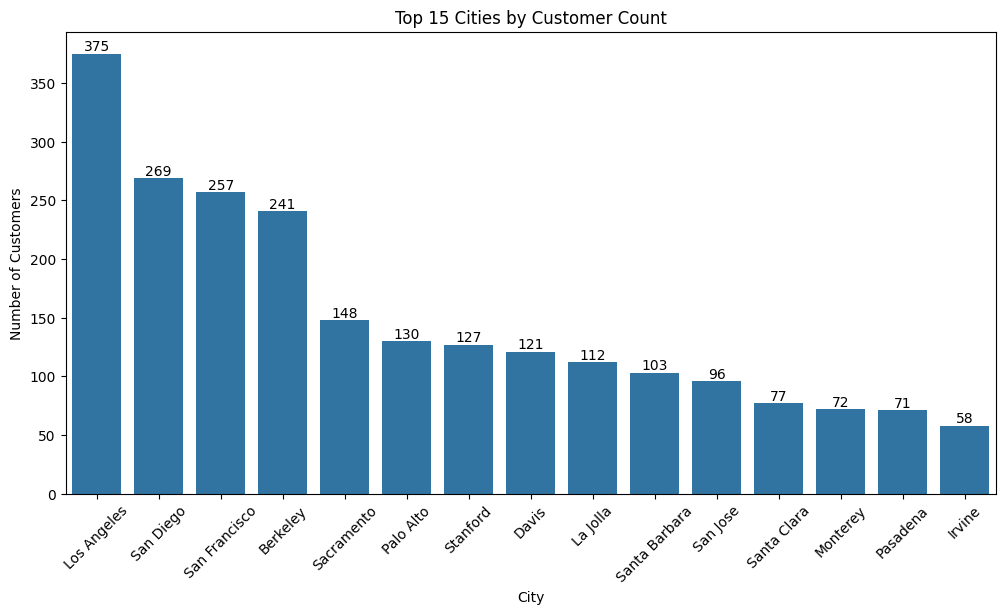

In [ ]:
top_cities = df['City'].value_counts().head(15)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Top 15 Cities by Customer Count")

plt.xlabel("City")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

####Observations:
- Los Angeles, San Diego, and San Francisco contain the highest number of customers. Many smaller cities have very few customer records.

### Distribution of City Frequencies

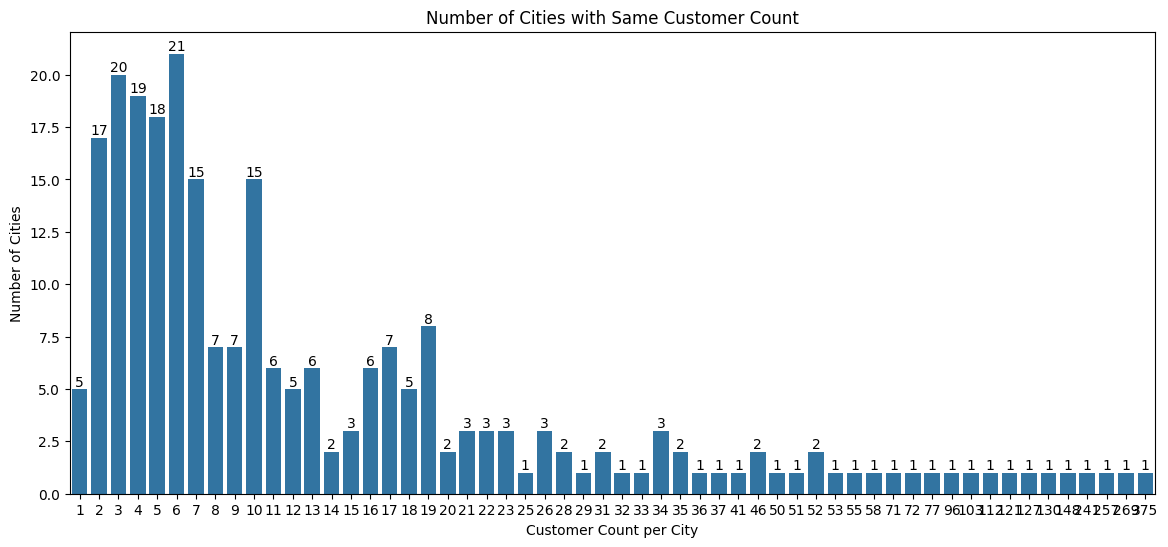

In [ ]:
city_counts = df['City'].value_counts()

same_count = city_counts.value_counts().sort_index()

plt.figure(figsize=(14,6))

ax = sns.barplot(
    x=same_count.index,
    y=same_count.values
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Number of Cities with Same Customer Count")

plt.xlabel("Customer Count per City")

plt.ylabel("Number of Cities")

plt.show()

####Observation:
- A large number of cities contain very few customers, confirming high cardinality and sparse representation in the City feature.

###Grouping Rare Cities

In [ ]:
# Keeping cities with at least 40 customers

major_cities = city_counts[city_counts >= 40].index

# Grouping smaller cities as 'Other'

df['City_Grouped'] = df['City'].apply(
    lambda x: x if x in major_cities else 'Other'
)

###Distribution After Grouping

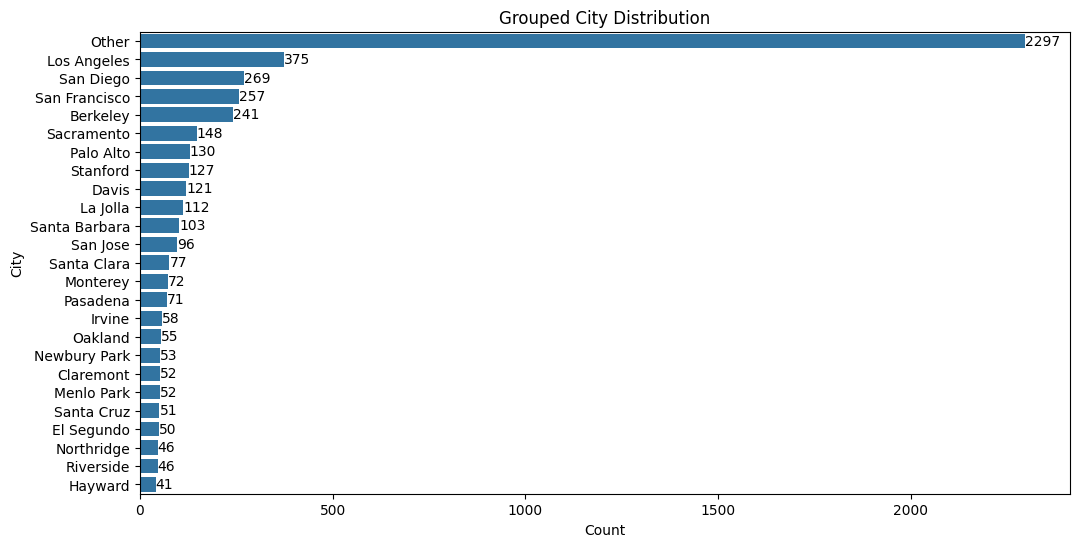

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    y='City_Grouped',
    data=df,
    order=df['City_Grouped'].value_counts().index
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Grouped City Distribution")

plt.xlabel("Count")

plt.ylabel("City")

plt.show()

####Observation:
- Rare cities were grouped into an “Other” category to reduce dimensionality and improve model generalization.
- Further, it would be encoded in preprocessing.

##3.3 Bivariate Analysis

##3.3.1 Correlation Heatmap

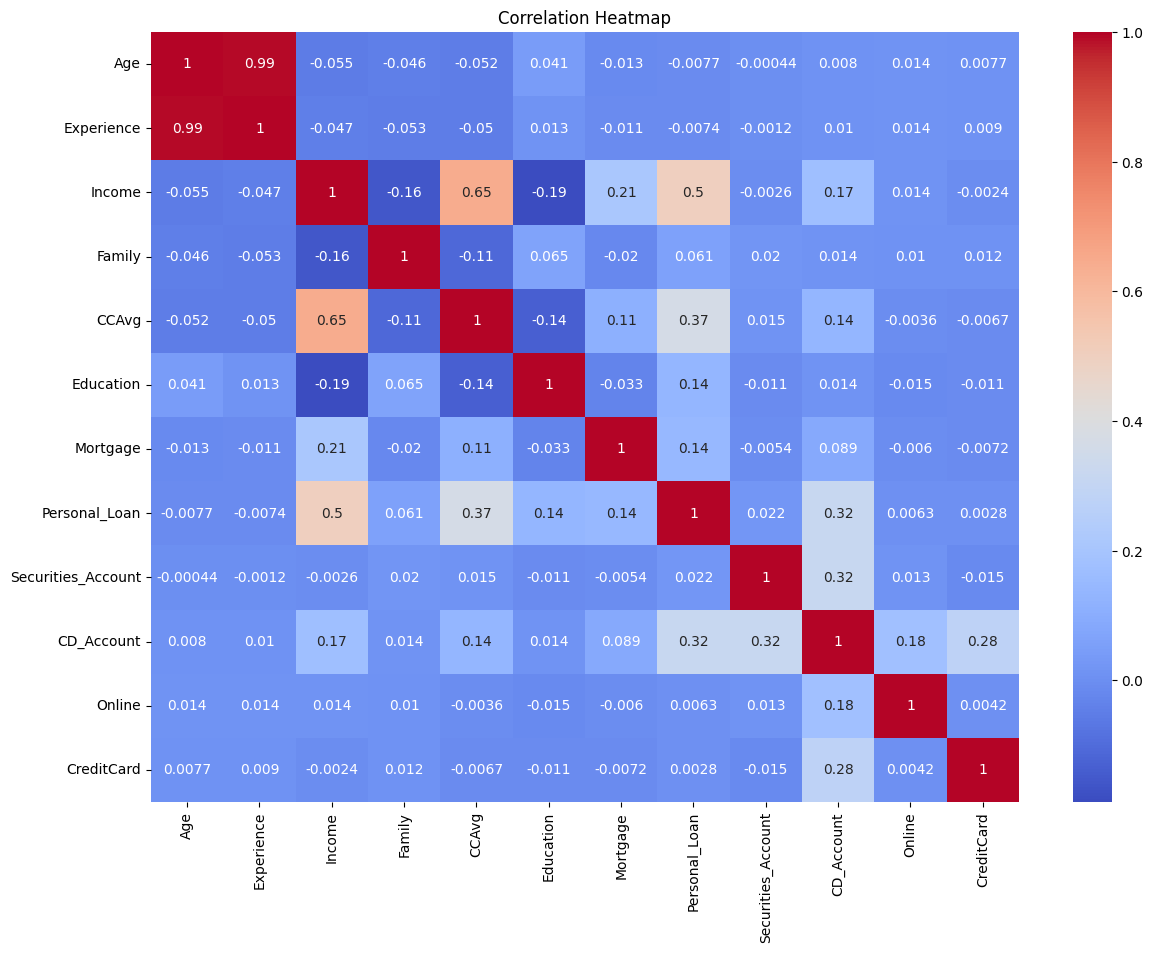

In [ ]:
df_corr = df.select_dtypes(include=['number'])

plt.figure(figsize=(14,10))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

####Observations from Correlation Heatmap
1. Age and Experience

- Age and Experience show an extremely strong positive correlation of approximately 0.99.

####Insight

- As customer age increases, professional experience also increases almost proportionally.
- This indicates strong multicollinearity between these two features.

2. Income and CCAvg

- Income and CCAvg have a moderately strong positive correlation of approximately 0.65.
####Insight

- Customers with higher income tend to spend more on credit cards.

3. Income and Personal Loan

- Income shows a strong positive correlation (0.50) with Personal_Loan.
####Insight

- Higher-income customers are more likely to accept personal loan offers, making income one of the strongest predictors.

4. CCAvg and Personal Loan

- CCAvg has a moderate positive correlation (0.37) with Personal_Loan.
####Insight

- Customers with higher credit card spending are more likely to purchase personal loans.

5. CD_Account and Personal Loan

- CD_Account shows a moderate positive correlation (0.32) with Personal_Loan.
####Insight

- Customers having a Certificate of Deposit (CD) account are more likely to accept personal loan offers.

6. Securities_Account and CD_Account

- Securities_Account and CD_Account show a moderate positive correlation (0.32).
####Insight

- Customers with investment-related banking products tend to possess multiple financial products with the bank.

7. Mortgage and Income

- Mortgage and Income have a weak-to-moderate positive correlation (0.21).
####Insight

- Customers with higher income tend to have larger mortgage amounts.

8. Education and Personal Loan

- Education has a weak positive correlation (0.14) with Personal_Loan.
####Insight

- Customers with higher education levels may have slightly higher likelihood of accepting loans.

9. Online and Personal Loan

- Online banking usage has almost no correlation with Personal_Loan.
####Insight

- Online banking usage alone may not strongly influence loan acceptance behavior.

####Overall Conclusion:
- The strongest predictors of personal loan acceptance appear to be:
Income,
CCAvg, and
CD_Account
- Age and Experience are highly correlated, indicating possible redundancy.
- Several features show weak correlations individually, but - Decision Tree models can still effectively capture non-linear relationships and feature interactions.

3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

The strongest predictors of personal loan acceptance are Income, CCAvg, and CD_Account. These features indicate that financially active and higher-income customers are more likely to accept personal loan offers.

4. How does a customer's interest in purchasing a loan vary with their education?

Education category 1 shows the lowest proportion of loan acceptance. While education categories 2 and 3 demonstrate relatively higher interest in personal loans.
Hence, customers with higher educational qualifications may possess greater financial awareness, higher income potential, and increased borrowing capacity, making them more likely to accept personal loan offers.

##3.3.2 Pairplot

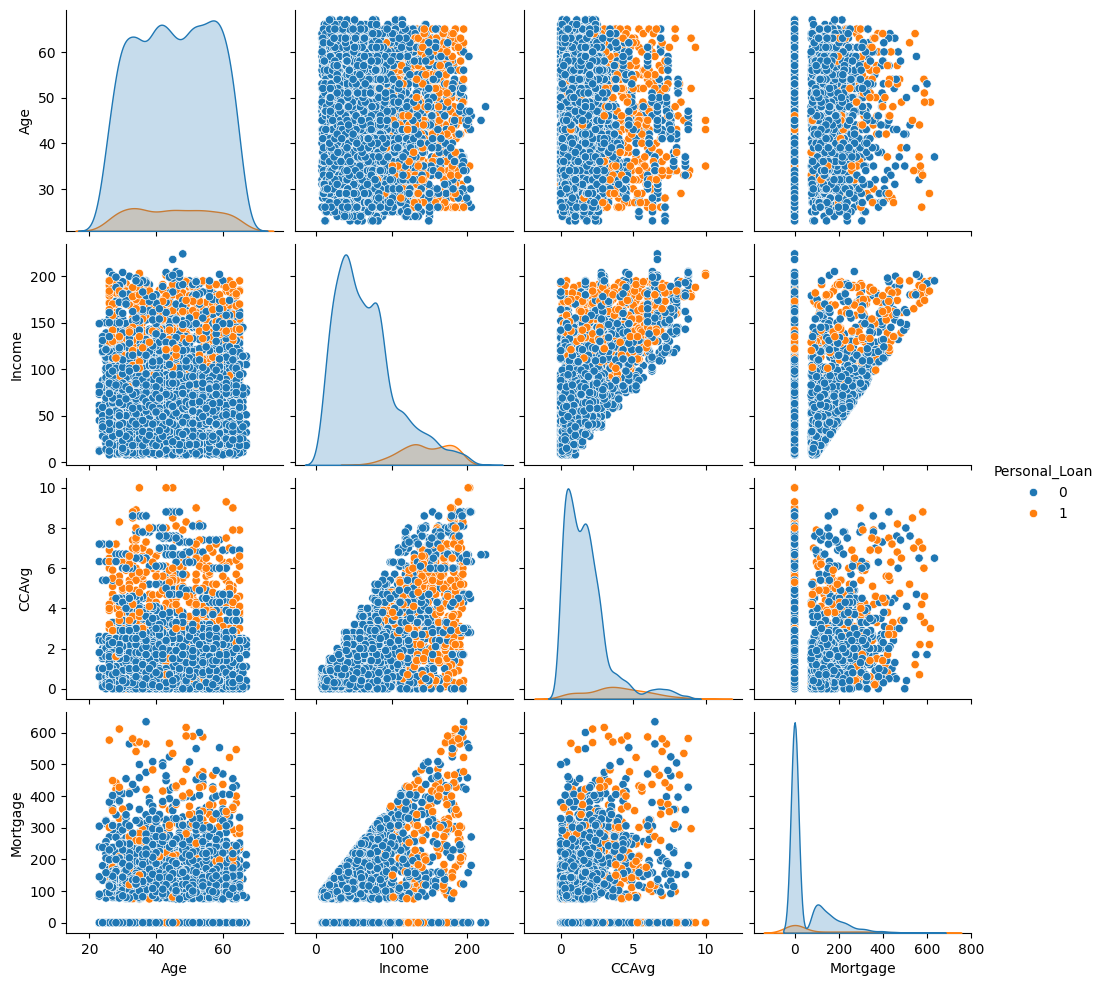

In [ ]:
sns.pairplot(
    df[
        [
            'Age',
            'Income',
            'CCAvg',
            'Mortgage',
            'Personal_Loan'
        ]
    ],
    hue='Personal_Loan'
)

plt.show()

####Observations from Pairplot
1. Income vs Personal Loan

- Customers who accepted personal loans (1) are concentrated more in higher income ranges.
- Customers with lower income predominantly belong to the non-loan category (0).
####Insight

- Income appears to be one of the strongest predictors of personal loan acceptance.

2. CCAvg vs Personal Loan

- Customers with higher credit card average spending (CCAvg) show greater tendency to accept personal loans.
- Loan-accepting customers are more concentrated in higher spending regions.
####Insight

- Financially active customers with high credit card spending are more likely to purchase personal loans.

3. Mortgage vs Personal Loan

- Customers with higher mortgage values show slightly higher loan acceptance behavior.
- However, many customers have zero mortgage values regardless of loan status.
####Insight

- Mortgage contributes some predictive information, but its relationship with personal loan acceptance is weaker compared to Income and CCAvg.

4. Income vs CCAvg

- A clear positive relationship exists between Income and CCAvg.
- As income increases, credit card spending also tends to increase.
####Insight

- Higher-income customers generally exhibit stronger spending behavior.

5. Income vs Mortgage

- Mortgage values tend to increase with income.
- Higher-income customers are more likely to possess larger mortgage amounts.
####Insight

- Customers with greater earning capacity often carry higher financial commitments.

6. Age vs Personal Loan

- Personal loan acceptance is distributed across different age groups without a very strong visible separation.
- Both loan and non-loan customers appear across most age ranges.
####Insight

- Age alone may not be a strong predictor of personal loan acceptance.

7. Distribution Patterns

- Income, CCAvg, and Mortgage exhibit right-skewed distributions.
- Mortgage contains a very high concentration near zero values.
- Loan-accepting customers are comparatively fewer due to target class imbalance.
####Overall Conclusion
- The pairplot indicates that:
Income,
CCAvg, and
Mortgage

are important financial indicators influencing personal loan acceptance.

- Customers accepting personal loans generally:
  - have higher income
  - spend more on credit cards
  - possess larger mortgage values
- The dataset also exhibits:
  - class imbalance
  - skewed financial variables
  - overlapping distributions across some features
- Although some variables do not show strong linear separation visually, Decision Tree models can still effectively capture non-linear relationships and feature interactions.

5. How does a customer's interest in purchasing a loan vary with their age?


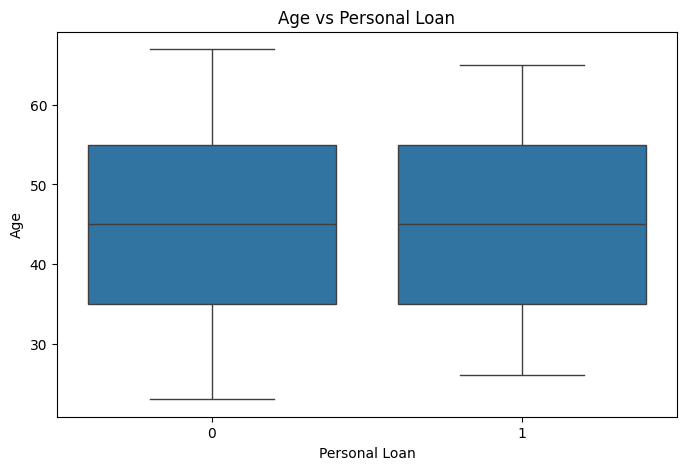

In [ ]:
# Boxplot of Age vs Personal Loan

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Personal_Loan',
    y='Age',
    data=df
)

plt.title("Age vs Personal Loan")

plt.xlabel("Personal Loan")

plt.ylabel("Age")

plt.show()

In [ ]:
# Creating age groups

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[20,30,40,50,60,70],
    labels=[
        '20-30',
        '31-40',
        '41-50',
        '51-60',
        '61-70'
    ]
)

In [ ]:
# Calculating loan acceptance percentage by age group

age_loan = pd.crosstab(
    df['Age_Group'],
    df['Personal_Loan'],
    normalize='index'
) * 100

age_loan

Personal_Loan,0,1
Age_Group,,
20-30,89.423077,10.576923
31-40,90.453074,9.546926
41-50,90.393701,9.606299
51-60,91.307634,8.692366
61-70,89.213894,10.786106


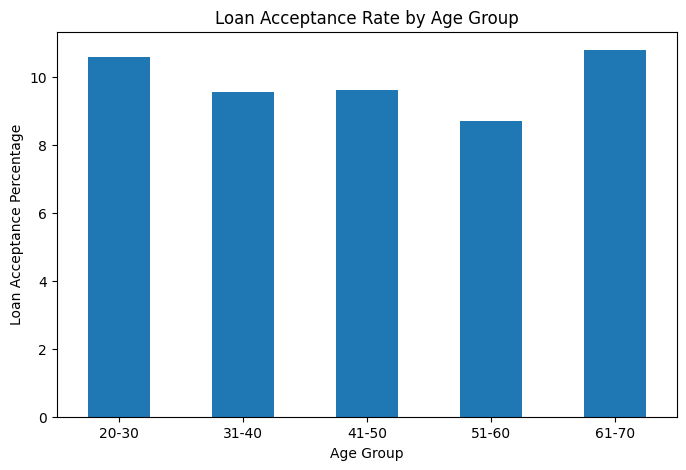

In [ ]:
# Plotting loan acceptance rate by age group

age_loan[1].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Loan Acceptance Rate by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Loan Acceptance Percentage")

plt.xticks(rotation=0)

plt.show()

####Observations:
- Loan interest is distributed across multiple age groups without extreme variation.
- Customers in the working-age and financially stable groups exhibit greater loan acceptance behavior.
- Very young and senior customers show comparatively lower loan interest.
####Insight

- Middle-aged customers are likely to have greater financial responsibilities, stable income, and higher borrowing requirements, making them more inclined toward personal loan products.



#4. Data Preprocessing

##4.1 Handling Outliers

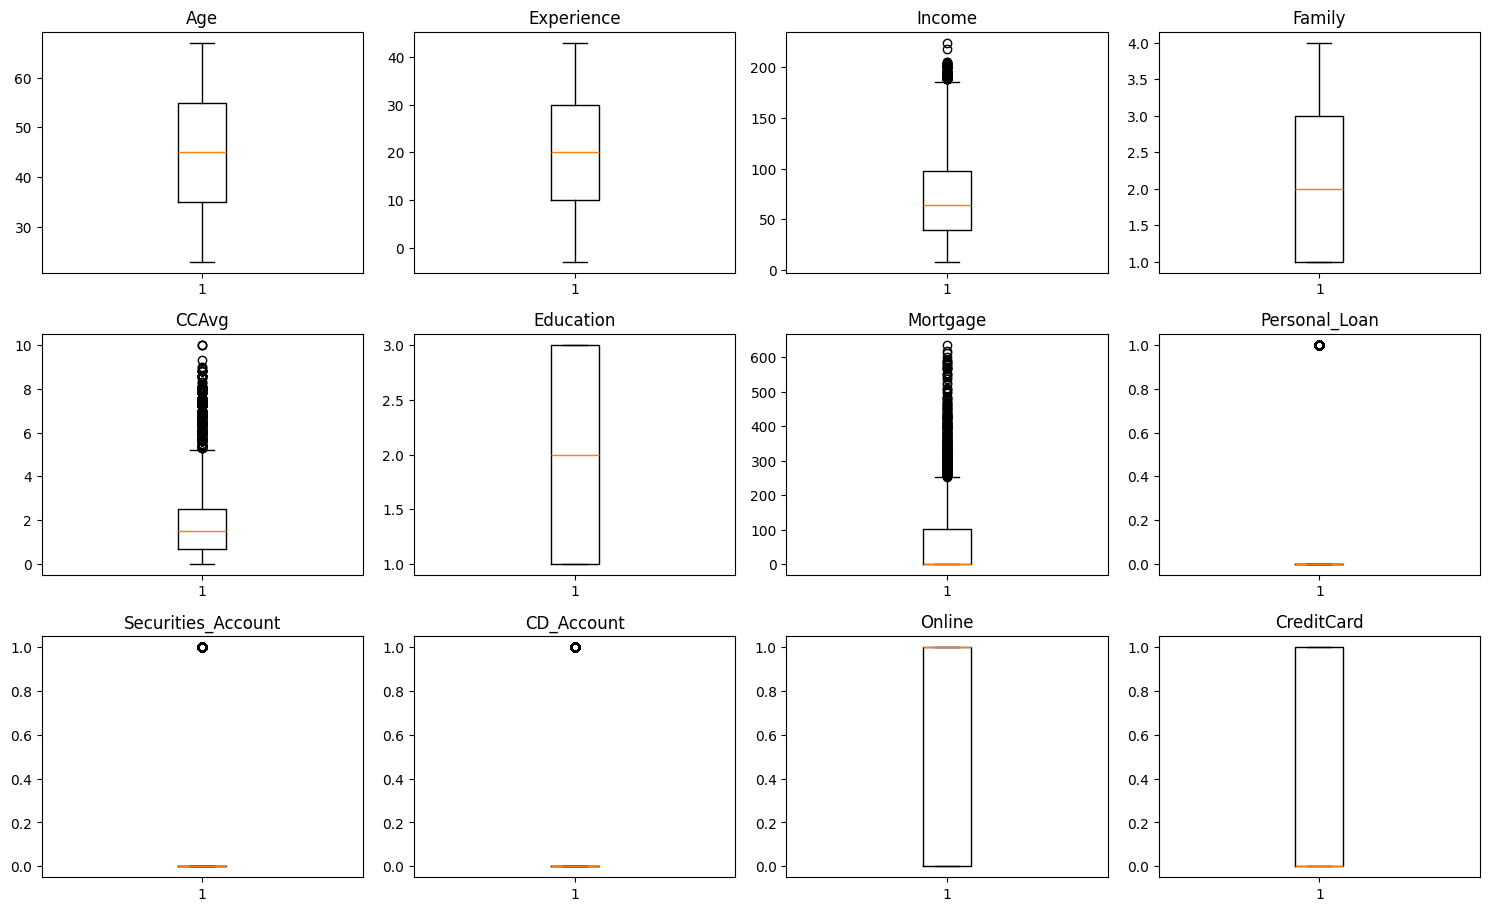

In [ ]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

####Observations:
1. Age

- The Age variable does not show significant outliers.
- Most customers belong to the middle-age working population.
- The distribution appears relatively symmetric and stable.
####Insight

- Age distribution is balanced and does not require outlier treatment.

2. Experience

- The Experience variable does not contain major outliers.
- Negative values are still visible, indicating invalid observations or data inconsistencies.
####Insight

- Negative experience values should be corrected during preprocessing.

3. Income

- The Income feature contains several upper-end outliers above approximately 180.
- Most customers belong to low-to-middle income groups.
- The distribution is positively skewed.
####Insight

- High-income customers form a smaller but financially strong customer segment and may be more likely to accept personal loan offers.

4. Family

- Family size ranges between 1 and 4 without any outliers.
- The distribution appears relatively balanced across categories.
####Insight

- Family size is a stable categorical feature that may influence customer financial requirements and borrowing behavior.

5. CCAvg

- The CCAvg feature contains a large number of upper-end outliers.
- Most customers have low average credit card spending, while a smaller segment exhibits very high spending behavior.
- The distribution is heavily right-skewed.
####Insight

- Customers with high credit card spending may represent financially active or premium customers and could be strong targets for loan campaigns.

6. Education

- Education is distributed across three ordinal categories without outlier issues.
####Insight

- Education is an ordinal categorical variable and does not require outlier treatment.

7. Mortgage

- The Mortgage feature contains a very large number of extreme upper-end outliers.
- A significant proportion of customers have zero mortgage values.
- The distribution is highly right-skewed.
####Insight

- Most customers do not possess mortgages, while a smaller group carries high mortgage liabilities.

8. Personal_Loan

- The target variable is binary with values 0 and 1.
- Boxplot interpretation is not meaningful for binary categorical variables.
####Insight

- Personal_Loan represents the binary classification target variable.

9. Securities_Account

- The feature is binary and highly concentrated at value 0.
- Very few customers possess securities accounts.
####Insight

- Securities account ownership is relatively uncommon among customers.

10. CD_Account

- The feature is binary and highly imbalanced toward value 0.
- Only a small proportion of customers possess CD accounts.
####Insight

- CD account holders form a small but potentially valuable customer segment.

11. Online

- The Online variable is binary and comparatively more balanced than other binary features.
- A large number of customers actively use online banking services.
####Insight

- Online banking adoption is relatively high among customers.

12. CreditCard

- The CreditCard variable is binary with more customers belonging to category 0.
- Fewer customers use external bank credit cards.
####Insight

- Most customers appear to rely on the bank’s own services rather than external credit cards.

####Overall Conclusion
- Significant outliers are present in:
Income,
CCAvg, and
Mortgage.
- Age, Family, and Education exhibit relatively stable distributions without major anomalies.
- Binary variables are not suitable for traditional outlier interpretation.
- Outliers were retained because they represent genuine high-value banking customers rather than data errors.
- Also, Decision Tree models are relatively robust to outliers, aggressive outlier removal may not be necessary.
- However, invalid negative values in Experience should be corrected during preprocessing.

##4.2 Handling Negative 'Experience' Values

The `Experience` column contains negative values which are not logically valid. We will replace these negative values with non-negative `Experience` values to ensure data consistency.

In [ ]:
df['Experience'].value_counts().sort_values(ascending=True)

,count
Experience,
43,3
-3,4
42,8
-2,15
-1,33
41,43
40,57
0,66
1,74


In [ ]:
df['Experience'].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

| Experience | Count |
| ---------- | ----- |
| -1         | 33    |
| -2         | 15    |
| -3         | 4     |

So, there are 52 invalid observations in the Experience column.

Interpretation:

- Negative professional experience is logically impossible and likely caused by:

  - Data entry errors
  - Incorrect data recording
  - Typographical mistakes

Treatment:

- Since only a small number of rows are affected:

  - Convert negative values into positive values using absolute transformation:

In [ ]:
# Converting negative values into positive values using absolute transformation
df['Experience'] = df['Experience'].abs()

Reasoning:
- Only 52 records are affected out of 5000.
- The magnitude still appears reasonable.
- Prevents unnecessary data loss.

##4.3 Handling Grouped Cities

In [ ]:
# One-hot encoding grouped cities
if 'City_Grouped' in df.columns:
    df = pd.get_dummies(
        df,
        columns=['City_Grouped'],
        drop_first=True
    )
else:
    print("'City_Grouped' column not found, likely already encoded.")

'City_Grouped' column not found, likely already encoded.


In [ ]:
## Viewing One Hot Encoding of City_Grouped
display(df.head())

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,...,City_Grouped_Pasadena,City_Grouped_Riverside,City_Grouped_Sacramento,City_Grouped_San Diego,City_Grouped_San Francisco,City_Grouped_San Jose,City_Grouped_Santa Barbara,City_Grouped_Santa Clara,City_Grouped_Santa Cruz,City_Grouped_Stanford
0,25,1,49,4,1.6,1,0,0,1,0,...,True,False,False,False,False,False,False,False,False,False
1,45,19,34,3,1.5,1,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
2,39,15,11,1,1.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,35,9,100,1,2.7,2,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
4,35,8,45,4,1.0,2,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


####Observations:
- Due to one hot encoding of grouped city feature, the total number of columns has become 38.

### Other Observation of the Given Dataset:
- Certain categorical variables in the dataset were already numerically encoded.
  - The Education variable uses ordinal encoding
  - binary variables such as Personal_Loan, CD_Account, and Online are label encoded using 0 and 1 values.

- No additional categorical encoding is required as the dataset was already provided in machine-learning-ready numerical format.

#5. Data Preparation for Modeling

##5.1 Separating Features and Target

In [ ]:
X = df.drop(['Personal_Loan', 'City', 'Age_Group'], axis=1)

y = df['Personal_Loan']

##5.2 Checking Feature Shape

In [ ]:
print(X.shape)

print(y.shape)

(5000, 35)
(5000,)


##5.3 Splitting Train and Test Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

##5.4 Checking Split Shapes

In [ ]:
print("X_train shape :", X_train.shape)

print("X_test shape :", X_test.shape)

print("y_train shape :", y_train.shape)

print("y_test shape :", y_test.shape)

X_train shape : (3500, 35)
X_test shape : (1500, 35)
y_train shape : (3500,)
y_test shape : (1500,)


##5.5 Checking Target Distribution After Split

In [ ]:
print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64


##6. Model Evaluation Criterion

####Resoning:
- The dataset is imbalanced because:

  - Most customers did not accept the personal loan.
  - Only a smaller percentage accepted the loan.

- Therefore:

  - Accuracy alone may not be sufficient.
  - Precision, Recall, and F1-score become important for evaluating minority class prediction performance.
- Final Evaluation Strategy:

  - The Decision Tree model will be evaluated using Accuracy Score, Confusion Matrix, Precision, Recall, and F1-Score.
  - Since the target variable is imbalanced, special attention will be given to Recall and F1-score to ensure effective identification of customers likely to accept personal loans.

####6.1 Model Performance Function

In [ ]:
# Function to compute different evaluation metrics

def model_performance_classification_sklearn(
    model,
    predictors,
    target
):
    """
    Function to compute classification model performance metrics

    model      : trained classifier
    predictors : independent variables
    target     : dependent variable
    """

    # Generating predictions
    pred = model.predict(predictors)

    # Computing evaluation metrics

    acc = accuracy_score(target, pred)

    recall = recall_score(target, pred)

    precision = precision_score(target, pred)

    f1 = f1_score(target, pred)

    # Creating dataframe for metrics

    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1-Score": f1,
        },
        index=[0],
    )

    return df_perf

####6.2 Confusion Matrix Function

In [ ]:
# Function to plot confusion matrix with percentages

def confusion_matrix_sklearn(
    model,
    predictors,
    target
):
    """
    Function to plot confusion matrix

    model      : trained classifier
    predictors : independent variables
    target     : dependent variable
    """

    # Generating predictions

    y_pred = model.predict(predictors)

    # Creating confusion matrix

    cm = confusion_matrix(target, y_pred)

    # Creating labels with percentages

    labels = np.asarray(
        [
            [
                "{0:0.0f}".format(item)
                + "\n"
                + "{0:.2%}".format(item / cm.flatten().sum())
            ]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    # Plotting heatmap

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues"
    )

    plt.ylabel("True Label")

    plt.xlabel("Predicted Label")

    plt.title("Confusion Matrix")

    plt.show()

#7. Model Building

##7.1. Default Decision Tree Model

In [ ]:
# Creating Decision Tree model

model0 = DecisionTreeClassifier(
    random_state=1
)
# Fitting model on training data

model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

###Predicting on Training and Testing Data

In [ ]:
# Predictions on training data

y_train_pred = model0.predict(X_train)

# Predictions on test data

y_test_pred = model0.predict(X_test)


### Confusion Matrix - Training Data

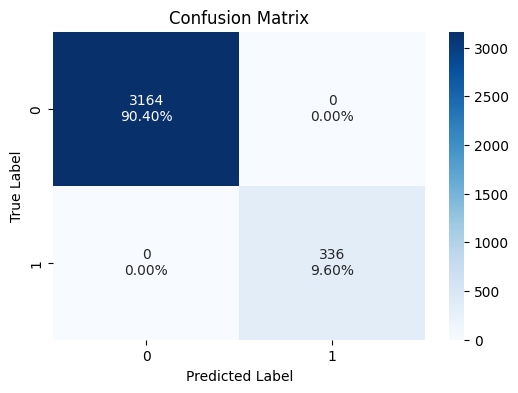

In [ ]:
confusion_matrix_sklearn(model0, X_train, y_train)

####Performance on Training Data

In [ ]:
model_performance_classification_sklearn_default = model_performance_classification_sklearn(
    model0,
    X_train,
    y_train
)
model_performance_classification_sklearn_default

,Accuracy,Recall,Precision,F1-Score
0,1.0,1.0,1.0,1.0


####Observation
- The Decision Tree model achieved:
  - Accuracy = 100%
  - Recall = 100%
  - Precision = 100%
  - F1-Score = 100%
- The training confusion matrix shows:
  - All observations classified correctly
  - No false positives
  - No false negatives
####Insight

The model has perfectly memorized the training dataset.



### Confusion Matrix - Testing Data

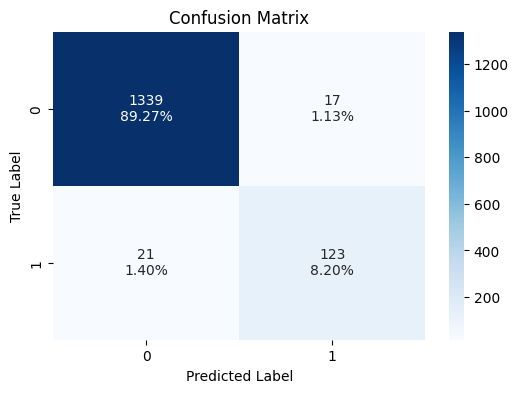

In [ ]:
confusion_matrix_sklearn(
    model0,
    X_test,
    y_test
)

####Observation

- From the testing confusion matrix:

  - True Negatives (TN) = 1339
  - True Positives (TP) = 123
  - False Positives (FP) = 17
  - False Negatives (FN) = 21
####Interpretation
- The model correctly classified most customers.
- Only:
  - 17 non-loan customers were incorrectly predicted as loan customers.
  - 21 actual loan customers were missed.
####Insight

- The model demonstrates strong predictive capability with relatively low classification error.

### Performance on Testing Data

In [ ]:
# Testing performance

model_performance_classification_sklearn(
    model0,
    X_test,
    y_test
)

,Accuracy,Recall,Precision,F1-Score
0,0.974667,0.854167,0.878571,0.866197


####Observation
- The model achieved strong performance on testing data:
  - Accuracy = 97.47%
  - Recall = 85.42%
  - Precision = 87.86%
  - F1-Score = 86.62%

- Recall = 85.42%, which means:
  - the model successfully identifies approximately 85% of customers who are likely to accept personal loans.
  - This is important because missing potential loan customers may reduce business opportunities.

- Precision = 87.86%, which means:

  - Among customers predicted as loan acceptors, nearly 88% actually accepted the loan.
  - This indicates:

    - Efficient targeting
    - Lower unnecessary marketing effort
####Insight

- The model generalizes well to unseen data and effectively identifies customers likely to accept personal loans.

- Overfitting Indication:

  - Training performance is perfect (100%)
  - Testing performance is slightly lower
####Insight

- The model shows signs of slight overfitting, which is common in Decision Trees because they tend to memorize training data.

- However, testing performance remains very high, so the model still generalizes effectively.

##7.2. Decision Tree (with class_weights)

In [ ]:
# Creating Decision Tree (with class_weights)

model1 = DecisionTreeClassifier(
    random_state=1, class_weight='balanced'
)
# Fitting model on training data

model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

###Predicting on Training and Testing Data

In [ ]:
# Predictions on training data

y_train_pred = model1.predict(X_train)

# Predictions on test data

y_test_pred = model1.predict(X_test)


### Confusion Matrix - Training Data

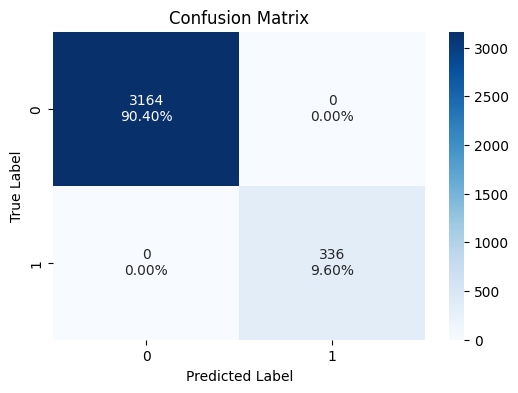

In [ ]:
confusion_matrix_sklearn(model1, X_train, y_train)

####Observation:
- The training confusion matrix shows:

  - True Negatives (TN) = 3164
  - True Positives (TP) = 336
  - False Positives (FP) = 0
  - False Negatives (FN) = 0
####Insight
- The Decision Tree model perfectly classified all training observations.
- This indicates that the model has completely learned the training data patterns without any classification errors.
- Perfect training performance suggests that the model may have memorized the training dataset, indicating possible overfitting.

### Confusion Matrix - Testing Data

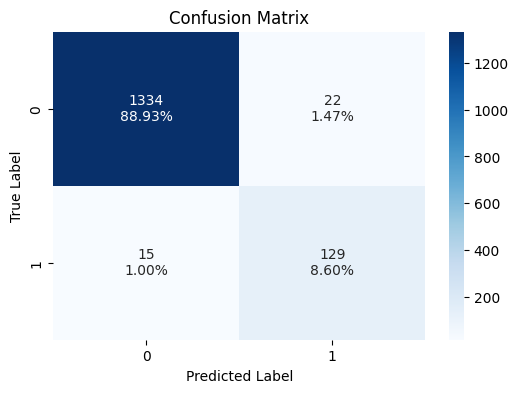

In [ ]:
confusion_matrix_sklearn(
    model1,
    X_test,
    y_test
)

####Observations:

- From the testing confusion matrix:

  - True Negatives (TN) = 1334
  - True Positives (TP) = 129
  - False Positives (FP) = 22
  - False Negatives (FN) = 15
- Interpretation
  - The model correctly classified the majority of customers.
  - Only:
    - 22 non-loan customers were incorrectly predicted as loan customers.
    - 15 actual loan customers were missed.
####Insight

  - The relatively low number of false negatives indicates strong capability in identifying potential loan customers.

####Performance on Training Data

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model1,
    X_train,
    y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1-Score
0,1.0,1.0,1.0,1.0


####Observation:
- model achieved:
  - Accuracy = 100%
  - Recall = 100%
  - Precision = 100%
  - F1-Score = 100%

####Performance on Testing Data

In [ ]:
# Testing performance

model_performance_classification_sklearn(
    model1,
    X_test,
    y_test
)

,Accuracy,Recall,Precision,F1-Score
0,0.975333,0.895833,0.854305,0.874576


####Observation
- The model achieved strong performance on testing data:
  - Accuracy = 97.53%
  - Recall = 89.58%
  - Precision = 85.43%
  - F1-Score = 87.46%
- Interpretation
  - Recall is approx. 90% which means the model successfully identifies nearly 90% of customers who are likely to accept personal loans.
  - Higher recall helps reduce missed loan sales opportunities.
  - 85% of Precision means among customers predicted as loan acceptors, approximately 85% actually accepted the loan. this helps improve marketing efficiency by reducing unnecessary targeting.
  - The model generalizes effectively to unseen data and performs very well in identifying customers likely to accept personal loans.

####Overall Model Interpretation

- Although the model performs perfectly on training data, it still maintains excellent performance on unseen testing data, indicating good generalization capability with only minor overfitting.

####Final Conclusion

This Decision Tree model demonstrates excellent predictive performance with high accuracy, recall, precision, and F1-score on testing data. The model effectively identifies customers likely to accept personal loans while maintaining low classification error. Despite slight overfitting, the model generalizes well and can serve as a strong predictive tool for targeted personal loan marketing campaigns.



##7.3. Decision Tree (Pre-pruning)

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [ ]:
# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10,
                       random_state=42)

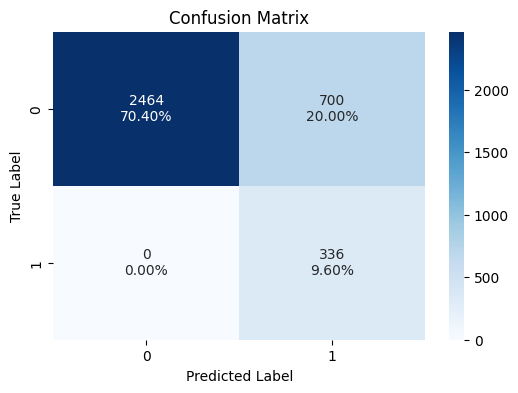

In [ ]:
confusion_matrix_sklearn(model2, X_train, y_train)

####Observation
  - True Negatives (TN) = 2464
  - False Positives (FP) = 700
  - False Negatives (FN) = 0
  - True Positives (TP) = 336

- All loan customers were correctly identified.
However, 700 non-loan customers were incorrectly predicted as loan customers.
####Insight

- The model avoids missing potential loan customers but significantly increases unnecessary marketing efforts.

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1-Score
0,0.8,1.0,0.324324,0.489796


####Observation:
- The model successfully identifies all actual loan customers, resulting in perfect recall.
- However, precision is very low because the model predicts many non-loan customers as loan customers.
- Accuracy is moderate at 80%.
####Insight

- The tuned model is highly aggressive in predicting loan acceptance and prioritizes identifying every possible loan customer, even at the cost of increased false positives.

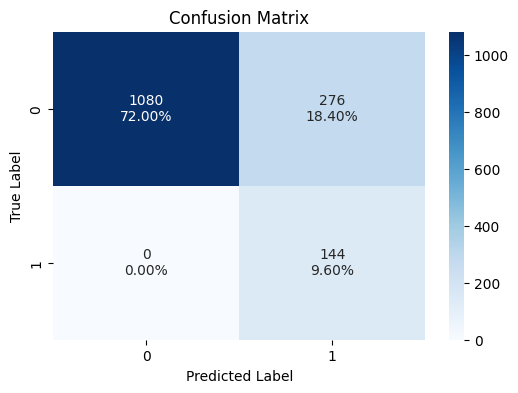

In [ ]:
confusion_matrix_sklearn(model2, X_test, y_test)

####Observation
  - True Negatives (TN) = 1080
  - False Positives (FP) = 276
  - False Negatives (FN) = 0
  - True Positives (TP) = 144

- The model correctly identifies every actual loan customer.
- However, many non-loan customers are still incorrectly targeted.

####Insight

- The model is highly recall-focused and suitable when missing potential loan customers is more costly than contacting uninterested customers.

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1-Score
0,0.816,1.0,0.342857,0.510638


####Observations:
- The model maintains perfect recall on unseen testing data.
- Precision remains low because many customers are incorrectly classified as loan acceptors.
- Accuracy slightly improves on testing data compared to training data.
####Insight

- The model generalizes consistently across training and testing data without severe overfitting.



###Feature Importance

In [ ]:
feature_names = list(X_train.columns)
importances = model2.feature_importances_
indices = np.argsort(importances)

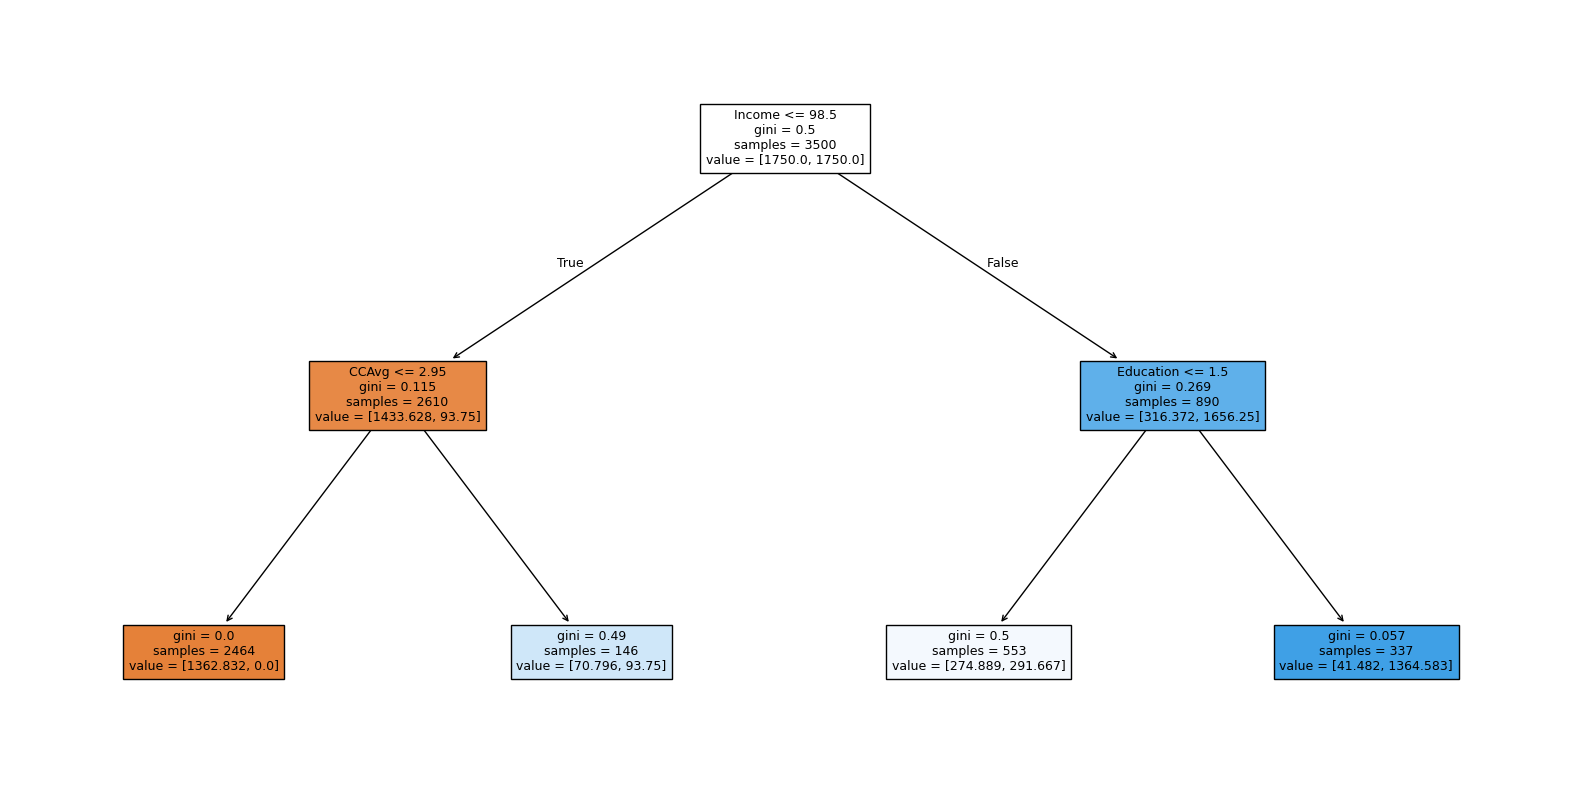

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()


####Decision Tree Structure Interpretation:
- Root Node - Income is the most important splitting variable in the model, indicating that customer income strongly influences loan acceptance.
- Secondary Split - Credit card spending behavior is another important indicator of loan acceptance probability.
- Education Split - Education level also contributes to distinguishing loan-accepting customers.




In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1362.83, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [70.80, 93.75] class: 1
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- weights: [274.89, 291.67] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [41.48, 1364.58] class: 1



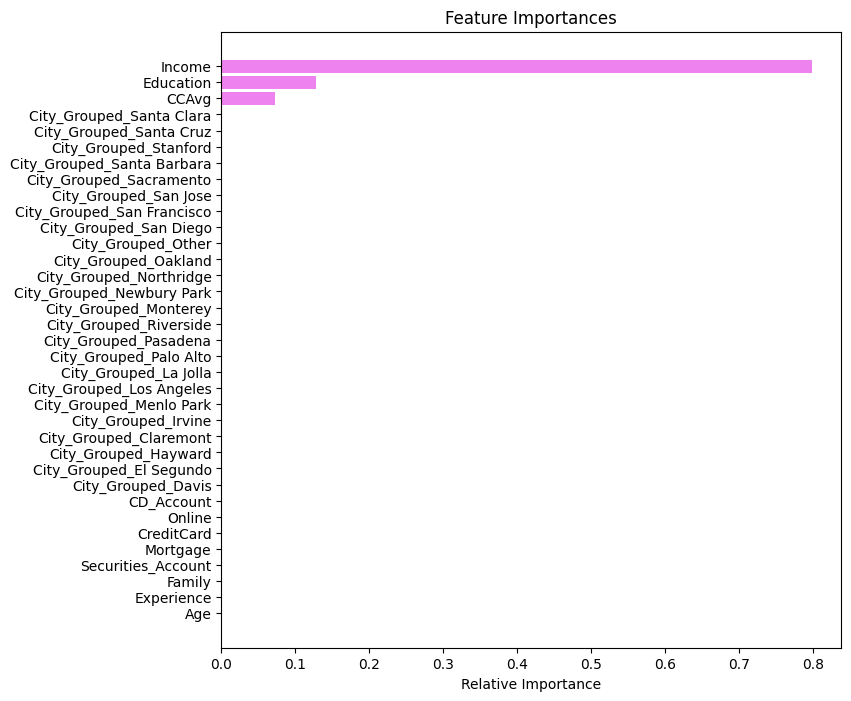

In [ ]:
# importance of features in the tree building

importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

####Observation:
- Income dominates prediction decisions.
Education and credit card spending contribute moderately.
- Most city variables and several financial variables contribute minimally.

####Insight
- Higher-income customers with larger spending behavior and stronger educational backgrounds are more likely to accept personal loans.

##7.4. Decision Tree (Post pruning)

In [ ]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-7.115802e-17
1,6.316060e-19,-7.052641e-17
2,6.316060e-19,-6.989481e-17
3,1.543926e-18,-6.835088e-17
4,1.649193e-18,-6.670169e-17
5,1.929907e-18,-6.477178e-17
6,3.070307e-18,-6.170148e-17
7,3.087852e-18,-5.861362e-17
8,4.175618e-18,-5.443801e-17
9,1.421114e-17,-4.022687e-17


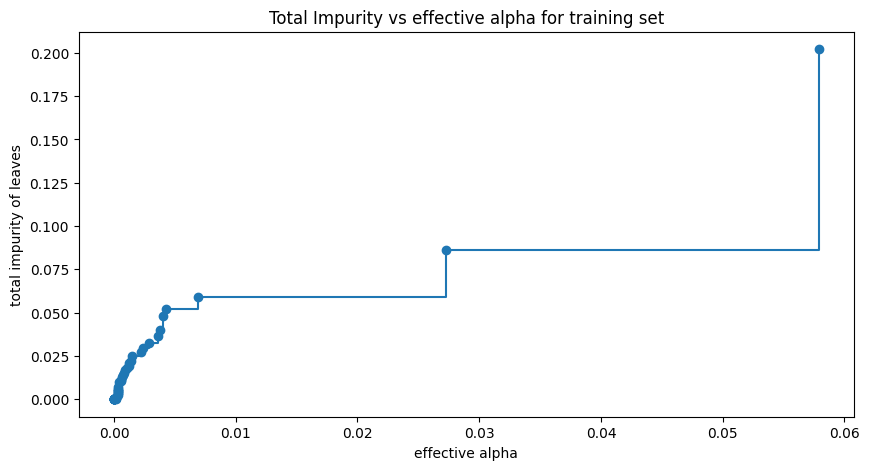

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

#####Observations:
- Initial Region - At alpha values close to 0, total impurity is very low.
  - The tree is highly complex and fits the training data very closely, resulting in very pure leaf nodes and overfitting.
- As alpha increases slightly, impurity increases gradually.
  - The tree begins pruning smaller branches, reducing complexity while slightly increasing impurity.
  - Moderate pruning helps improve generalization by reducing overfitting.
- Around alpha values near 0.028 and especially 0.058, impurity rises sharply.
  - Excessive pruning removes too many branches, making the model overly simple.
  - The model may begin underfitting because it loses important decision-making patterns.
####Insight

- The Cost Complexity Pruning graph indicates that increasing alpha gradually simplifies the Decision Tree by pruning branches and increasing impurity.
- Very small alpha values produce highly complex trees that may overfit the training data, whereas very large alpha values oversimplify the model and may cause underfitting.
- The optimal pruning level lies before the sharp increase in impurity, where the model achieves a balance between complexity and generalization.

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.29792729936894524


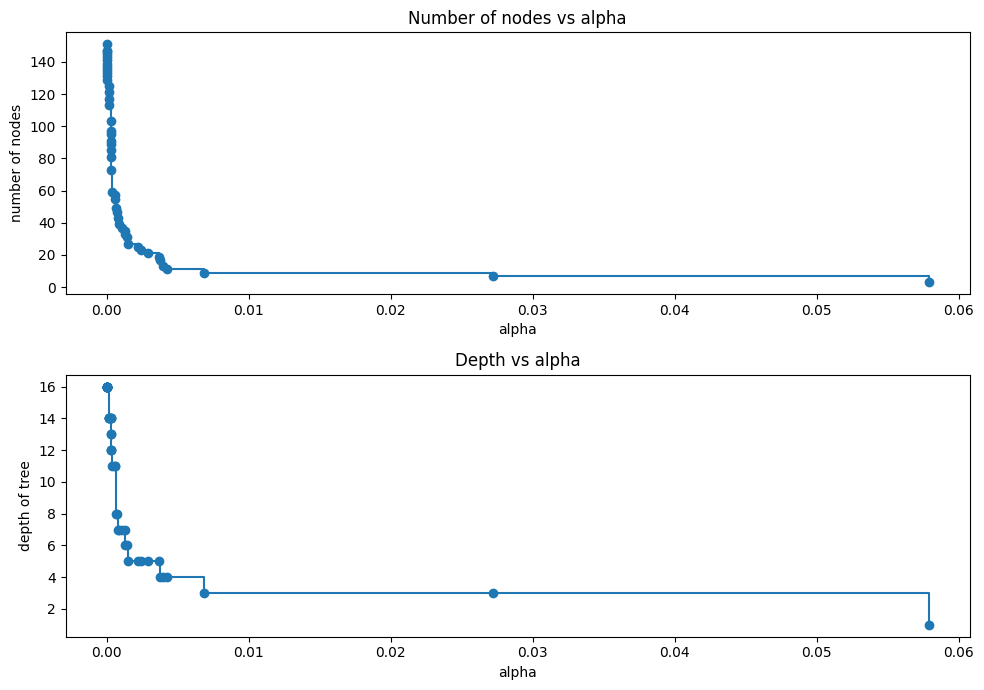

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

####Observations:
1. Number of Nodes vs Alpha

- At very small alpha values, the Decision Tree contains a large number of nodes (around 150).
- As alpha increases, the number of nodes decreases sharply.
- At higher alpha values, the tree becomes extremely small with very few nodes.
####Interpretation
- Small Alpha Values

  - Small alpha values produce highly complex trees with many nodes and branches.

  - The model learns detailed patterns from the training data.
  - This increases the risk of overfitting.
- Increasing Alpha

  - As alpha increases, pruning removes unnecessary branches.

    - Tree complexity reduces
    - Model becomes simpler
    - Generalization improves
- Large Alpha Values

  - Very large alpha values produce overly simplified trees with very few nodes.

  - Important decision rules may be lost
  - Model may underfit the data

2. Depth vs Alpha

- At alpha near 0, tree depth is very high (up to depth 16).
- As alpha increases, tree depth gradually decreases.
- At high alpha values, depth reduces to only 1–3 levels.
###Interpretation
- Deep Trees at Low Alpha

  - Low alpha values allow the tree to grow deeper and capture complex relationships.

  - However:

    - Deep trees memorize training data
    - Overfitting becomes more likely
- Reduced Depth at Higher Alpha

  - Pruning simplifies the decision tree by reducing depth.

  - Benefits:

    - Better interpretability
    - Reduced variance
    - Improved generalization
- Extremely Shallow Trees

  - Very high alpha values create shallow trees that may miss important data patterns.

  - This may cause:

    - Underfitting
    - Lower predictive accuracy

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

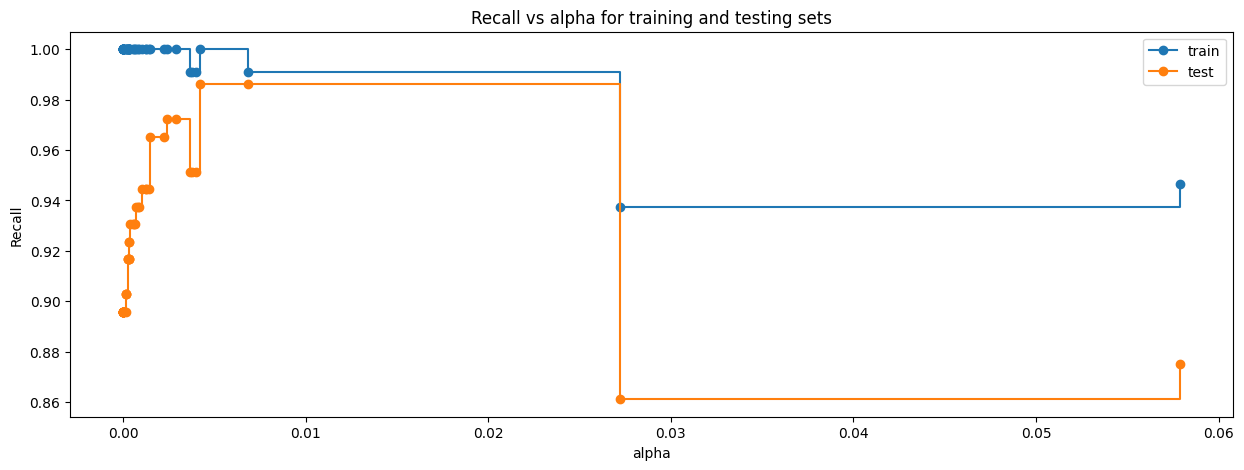

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

####Observations:

1. Recall at Low Alpha Values

- At alpha values close to 0:
- Training recall is nearly 100%
- Testing recall is also very high (~90%–97%)

####Interpretation

- The model is highly effective at identifying actual loan customers when pruning is minimal.

####Insight

- The tree is very complex and captures detailed patterns in the data.

- However, extremely low alpha values may increase overfitting risk.

2. Recall Stability Region

- Between approximately 0.004 and 0.027, both training and testing recall remain consistently high.
####Interpretation

- Moderate pruning does not significantly reduce the model’s ability to identify loan customers.

####Insight

- This region represents a strong balance between:

  - recall performance
  - reduced complexity
  - better generalization

3. Sharp Decline in Recall

- Around alpha ≈ 0.028, testing recall drops sharply from about 98% to 86%.
####Interpretation

- Excessive pruning removes important decision branches responsible for identifying positive loan cases.

####Insight

- The model begins underfitting and loses predictive capability.

4. Training vs Testing Recall Comparison

- Training recall remains consistently higher than testing recall across all alpha values.
####Interpretation

- The model performs slightly better on training data, which is expected because the model learns directly from it.

####Insight

- The relatively small gap between training and testing recall suggests that pruning improves generalization and reduces severe overfitting.



In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.004240658160900034),
                       class_weight='balanced', random_state=1)


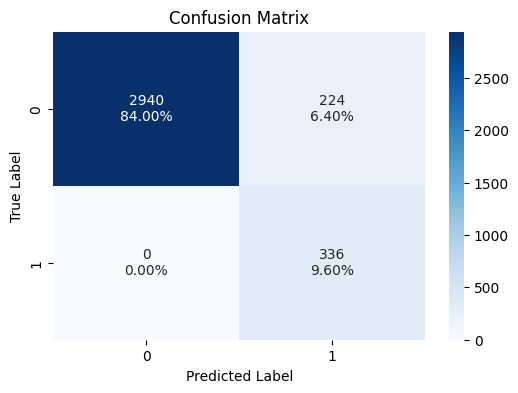

In [ ]:
model4 = best_model
confusion_matrix_sklearn(model4, X_train, y_train)

####Observation:
- TN - 2940 customers who did not accept personal loans were correctly classified by the model.
- TP - All 336 customers who accepted personal loans were correctly identified.
- FP - 224 customers were incorrectly predicted as loan acceptors even though they did not accept loans.
- FN - No actual loan customers were missed by the model.

####Insight
- In personal loan marketing, missing an actual loan customer may be more costly than contacting some uninterested customers. Therefore, this model is useful in scenarios where maximizing customer acquisition is the primary objective.

In [ ]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model4, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1-Score
0,0.936,1.0,0.6,0.75


####Observation:
- Accuracy
  - The model correctly classified approximately 93.6% of the training observations.
  - The model successfully identified all actual loan customers in the training data.
- Precision
  - Among customers predicted as loan acceptors, only 60% actually accepted the loan.
  - The model still produces a noticeable number of false positives.
  - Some uninterested customers may receive unnecessary loan offers, increasing marketing effort.
- Recall
  - The model successfully identified all actual loan customers in the training data.
  - No potential loan customers were missed, which is highly beneficial for loan marketing campaigns.
- F1 Score (75%)
  - The model maintains a reasonable balance between recall and precision.
  - The model strongly prioritizes recall while maintaining acceptable precision.

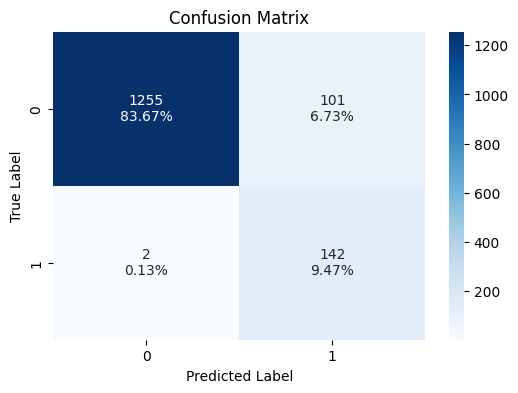

In [ ]:
confusion_matrix_sklearn(model4, X_test, y_test)

####Observations:
- True Negatives
  - 1255 customers who did not accept personal loans were correctly classified by the model.
  - The model performs effectively in identifying non-loan customers.
- True Positives
  - 142 customers who accepted personal loans were correctly identified.
  - The model successfully captures nearly all actual loan customers.
- False Positives
  - 101 customers were incorrectly predicted as loan acceptors even though they did not accept loans.
  - Some additional marketing resources may be spent targeting uninterested customers.
- False Negatives
  - Only 2 actual loan customers were missed by the model.
  - The model minimizes missed business opportunities by identifying almost every potential loan customer.

In [ ]:
decision_tree_post_test = model_performance_classification_sklearn(
    model4, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1-Score
0,0.931333,0.986111,0.584362,0.73385


####Observations:
- Accuracy
  - The model correctly classified approximately 93.1% of the testing observations.
  - The model demonstrates strong overall predictive capability on unseen data.
- Recall (98.6%)
  - The model successfully identified almost all actual loan customers.
  - Very few potential loan customers were missed, which is highly beneficial for maximizing business opportunities.
- Precision
  - Around 58% of customers predicted as loan acceptors actually accepted the loan.
  - Although the model captures most loan customers, it still predicts some non-loan customers as positive cases.
- F1 Score (73.39%)
  - The model maintains a good balance between recall and precision.
  - The model effectively balances identifying loan customers while reducing excessive false positive predictions.

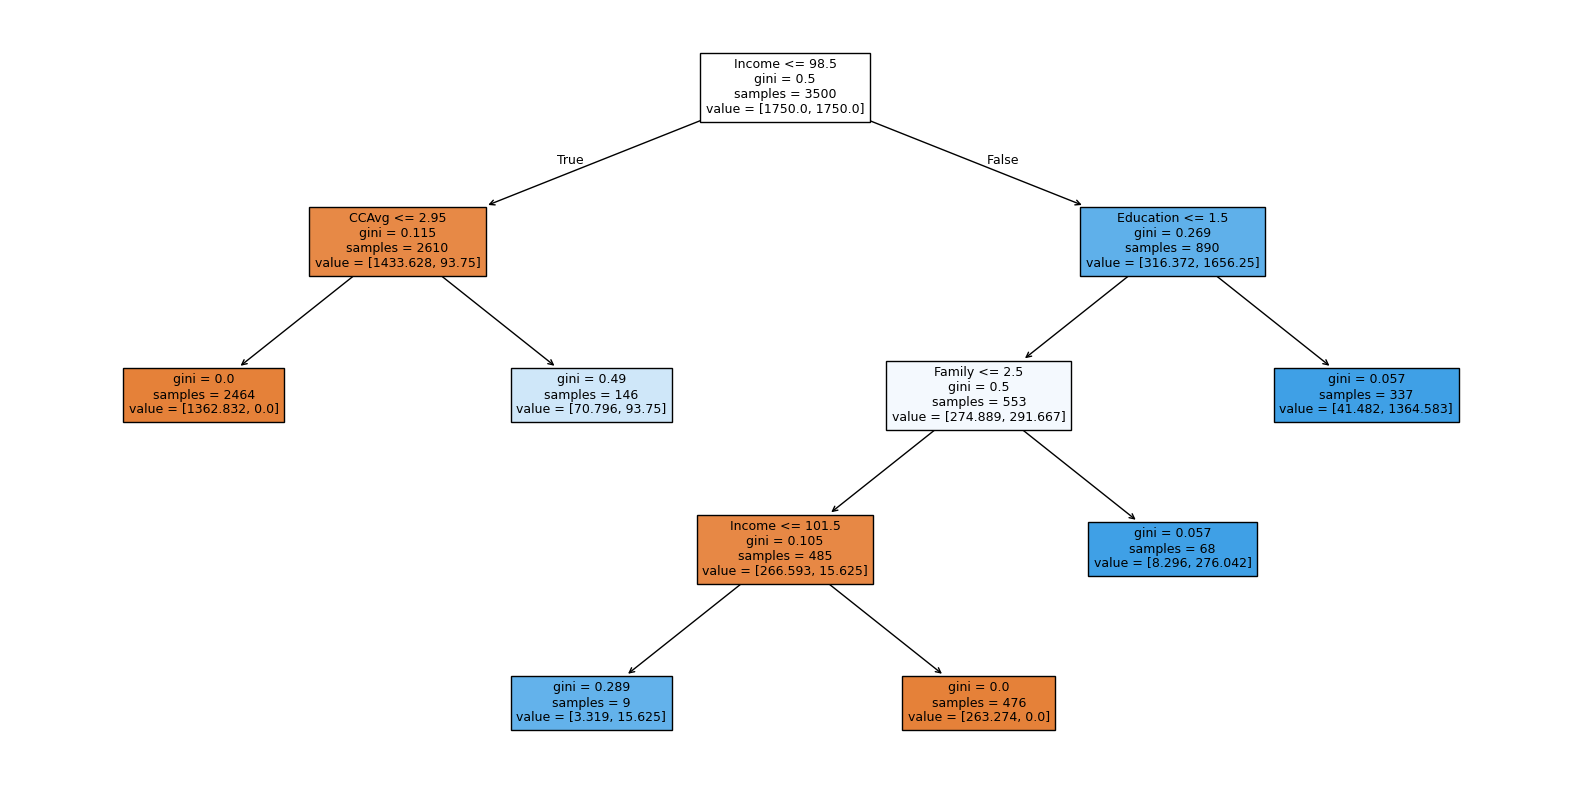

In [ ]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model4,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

####Decision Tree Interpretation
1. Root Node
- Income is the most important feature in the Decision Tree.
- Customers with income less than or equal to 98.5 mostly belong to the non-loan category.
- Customers with income greater than 98.5 are more likely to accept personal loans.
####Insight

- Higher-income customers show significantly greater interest in personal loan products.

2. Left Subtree (Lower Income Customers)
- Among lower-income customers, credit card spending (CCAvg) further separates loan behavior.
- Customers with low credit card spending (<= 2.95) almost never accept loans.

- Pure Non-Loan Node (gini =0.0, samples=2464)
  - This node is perfectly pure.
  - Nearly all customers in this segment do not accept personal loans.

- Mixed Node (gini=0.49, samples=146)
  - Customers in this group show mixed behavior.
  - Some customers may still accept loans despite lower income levels.

3. Right Subtree (Higher Income Customers)
- Education becomes important among high-income customers.
- Customers with higher education levels show stronger loan acceptance behavior.

- Family-Based Split
  - Family size further distinguishes loan acceptance patterns among high-income customers.
  - Customers with larger families may exhibit greater financial needs and higher borrowing tendencies.

- Income-Based Split
  - Even within high-income groups, income continues to influence loan acceptance probability.
  - Pure Loan Node (gini-0.0, samples=476)
    - This node perfectly classifies customers likely to accept loans.
    - Customers in this segment represent highly promising targets for loan marketing campaigns.

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model4, feature_names=feature_names, show_weights=True))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1362.83, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [70.80, 93.75] class: 1
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 101.50
|   |   |   |   |--- weights: [3.32, 15.62] class: 1
|   |   |   |--- Income >  101.50
|   |   |   |   |--- weights: [263.27, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [8.30, 276.04] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [41.48, 1364.58] class: 1



In [ ]:
importances = model4.feature_importances_
indices = np.argsort(importances)

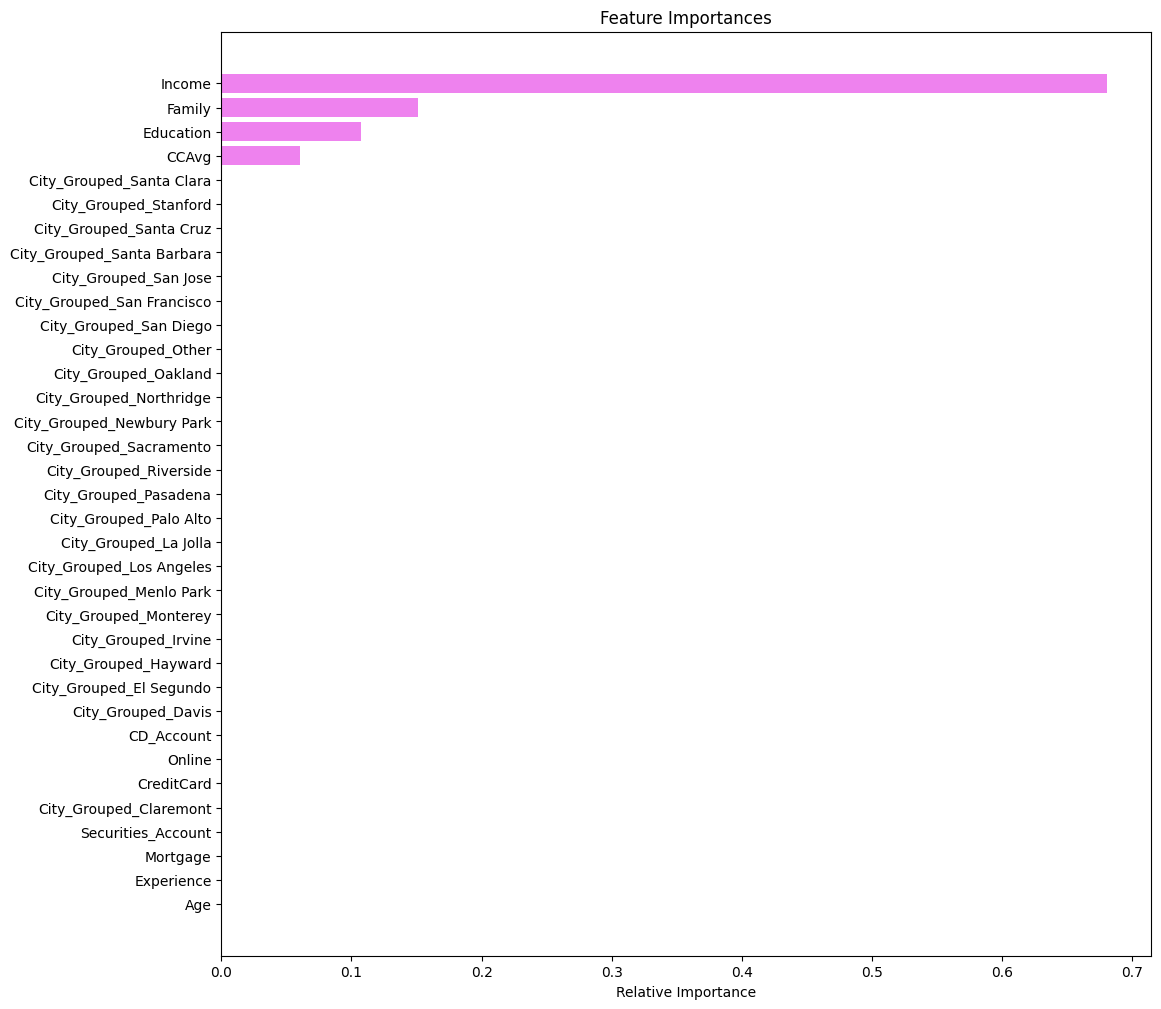

In [ ]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

####Observations:
1. Income (Most Important Feature)

- Income has the highest importance by a very large margin.
####Insight

- Income is the dominant factor influencing personal loan acceptance.
- Customers with higher income are significantly more likely to accept personal loans because they:

  - possess greater repayment capacity
  - qualify for larger loans
  - demonstrate stronger financial stability
2. Family

- Family is the second most important feature.
####Insight

- Family size affects customer financial requirements and borrowing behavior.

- Customers with larger families may require additional financial support for:

  - education
  - housing
  - healthcare
  - lifestyle expenses

making them more likely to accept personal loans.

3. Education

- Education contributes moderately to predictions.
####Insight

- Education level influences financial awareness and decision-making.
- Highly educated customers may:

  - better understand financial products
  - possess higher earning potential
  - exhibit greater willingness to utilize loans
4. CCAvg

CCAvg also contributes to loan prediction.
#### Insight

- Higher credit card spending indicates stronger financial activity and purchasing behavior.
- Customers with higher spending patterns may show greater interest in personal loan products.

5. Features with Negligible Importance

- The following features contribute very little or almost nothing:

  - Age
  - Experience
  - Mortgage
  - CreditCard
  - Online
  - CD_Account
  - Securities_Account
  - Most City variables
####Interpretation

- These features do not significantly influence the model’s decision-making process.

6. City Variable Interpretation

- Most grouped city variables have near-zero importance.
####Insight

- Geographic location does not strongly affect loan acceptance behavior in this dataset.
- Financial and behavioral attributes are far more influential than customer location.

#8. Comparison of Models and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_performance_classification_sklearn_default.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.800000,0.936
Recall,1.0,1.0,1.000000,1.000
Precision,1.0,1.0,0.324324,0.600
F1-Score,1.0,1.0,0.489796,0.750


In [ ]:
# Test performance comparison

models_test_comp_df = pd.concat(
    [
        model_performance_classification_sklearn(model0, X_test, y_test).T,
        model_performance_classification_sklearn(model1, X_test, y_test).T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.974667,0.975333,0.816000,0.931333
Recall,0.854167,0.895833,1.000000,0.986111
Precision,0.878571,0.854305,0.342857,0.584362
F1-Score,0.866197,0.874576,0.510638,0.733850


#### Interpretation of Model Comparison
1. Decision Tree (Sklearn Default)

- Achieved excellent training and testing performance with high accuracy, precision, recall, and F1-score. However, perfect training performance indicates slight overfitting.

2. Decision Tree with Class Weight

- Improved recall on testing data, meaning the model identified more loan customers, but precision decreased slightly due to more false positive predictions.

3. Decision Tree (Pre-Pruning)

- Achieved perfect recall by identifying all loan customers, but precision and accuracy dropped significantly because many non-loan customers were incorrectly classified.

4. Decision Tree (Post-Pruning)

- Produced the best balance between recall and precision. It reduced false positives while maintaining very high recall and strong overall performance.

#9. Conclusions and Recommendations

Based on the analysis and Decision Tree modeling, the following recommendations are suggested for the bank’s personal loan marketing strategy:

1. Target High-Income Customers

- Income emerged as the strongest predictor of personal loan acceptance.

- Recommendation
  - Focus marketing campaigns on customers with higher income levels.
  - Prioritize financially stable customers with strong repayment capacity.
2. Target Customers with Higher Credit Card Spending

- Customers with higher CCAvg showed greater interest in personal loans.

- Recommendation
  - Use credit card spending behavior as an important customer segmentation factor.
  - Target financially active customers for cross-selling loan products.
3. Focus on Highly Educated Customers

- Education showed a positive relationship with loan acceptance.

- Recommendation
  - Develop specialized loan offers for professional and highly educated customers.
  - Use personalized financial campaigns for this segment.
4. Use Family Size for Customer Segmentation

- Customers with larger families demonstrated higher loan interest.

- Recommendation
  - Promote loans designed for:
  - education expenses
  - home improvements
  - family financial needs
5. Deploy the Post-Pruned Decision Tree Model

- The post-pruned model provided the best balance between:

  - accuracy
  - recall
  - precision
  - generalization
- Recommendation
  - Use the post-pruned Decision Tree for real-world prediction and customer targeting.
  - It minimizes overfitting while maintaining strong predictive performance.
6. Reduce Unnecessary Marketing Costs

- Aggressive models generated many false positives.

- Recommendation
  - Use balanced models to avoid targeting too many uninterested customers.
  - Optimize campaign efficiency using model predictions.

####Overall Conclusion

The project successfully developed a Decision Tree classification model to predict whether customers are likely to accept personal loan offers. Through extensive exploratory data analysis, important patterns and relationships were identified within customer financial and demographic attributes.